# Thesis figures notebook

Notebook này là guided thesis-analysis notebook cho bộ hình benchmark. Mỗi figure bao gồm:

- Heading riêng.
- Block giải thích mục đích, dữ liệu, cách đọc và điểm cần quan sát.
- Code cell sinh đúng figure đó.
- Một ghi chú ngắn về cách diễn giải.

Tài liệu diễn giải chi tiết nhất nằm tại:

`docs/thesis_figure_analysis.md`

Notebook này dùng để tái sinh hình và đọc nhanh theo mạch tự sự (narrative): **calibration -> S1 -> S2 -> repeatability -> S3**.

## Thiết lập và Nạp dữ liệu

Cell này tìm thư mục gốc của repository (repo root), nạp các tệp CSV phân tích, import pipeline vẽ biểu đồ từ `scripts/generate_charts.py`, và định nghĩa các hàm hỗ trợ (helper) để hiển thị hình ảnh vừa được sinh ra.

In [ ]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "results_analysis" / "comparison_AB.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find repository root")


REPO_ROOT = find_repo_root()
ANALYSIS_DIR = REPO_ROOT / "results_analysis"
OUT_DIR = REPO_ROOT / "docs" / "figures" / "thesis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(REPO_ROOT / "scripts"))
import generate_charts as charts

aggregated, comparison = charts.load_csvs(ANALYSIS_DIR)
repeatability_raw = charts.repeatability_raw_p99(REPO_ROOT)
repeatability_summary = charts.repeatability_summary(repeatability_raw)
calibration_selection_path = ANALYSIS_DIR / "calibration_load_selection.csv"
calibration_selection = pd.read_csv(calibration_selection_path) if calibration_selection_path.exists() else pd.DataFrame()


def show_fig(name: str) -> None:
    path = OUT_DIR / f"{name}.png"
    if not path.exists():
        raise FileNotFoundError(path)
    display(Image(filename=str(path)))


print("repo:", REPO_ROOT)
print("aggregated:", aggregated.shape)
print("comparison:", comparison.shape)
print("repeatability raw:", repeatability_raw.shape)


repo: D:\Project\NT531_EKS\NT531_EKS-Cilium-Kubeproxy-Benchmark
aggregated: (34, 57)
comparison: (90, 18)
repeatability raw: (84, 10)


## Kiểm tra các bảng dữ liệu đầu vào (Inspect input tables)

Bước này giúp kiểm tra xem notebook có đang đọc đúng các kết quả đầu ra (outputs) hiện tại hay không. Nếu cấu trúc dữ liệu (schema) có sự thay đổi, bạn nên dừng lại để hiệu chỉnh trước khi tiến hành diễn giải các hình ảnh.

In [2]:
print("comparison_AB columns:")
print(list(comparison.columns))

print("\naggregated_summary columns:")
print(list(aggregated.columns))

if not calibration_selection.empty:
    print("\ncalibration_load_selection:")
    display(calibration_selection)

print("\nrepeatability summary head:")
display(repeatability_summary.head())


comparison_AB columns:
['scenario', 'load', 'phase', 'metric', 'A_mean', 'A_ci_lo', 'A_ci_hi', 'A_stdev', 'A_n', 'B_mean', 'B_ci_lo', 'B_ci_hi', 'B_stdev', 'B_n', 'delta_pct', 'p_value', 'significant', 'winner']

aggregated_summary columns:
['group', 'p50_ms_median', 'p50_ms_mean', 'p50_ms_stdev', 'p50_ms_n', 'p50_ms_ci_lo', 'p50_ms_ci_hi', 'p50_ms_min', 'p50_ms_max', 'p90_ms_median', 'p90_ms_mean', 'p90_ms_stdev', 'p90_ms_n', 'p90_ms_ci_lo', 'p90_ms_ci_hi', 'p90_ms_min', 'p90_ms_max', 'p99_ms_median', 'p99_ms_mean', 'p99_ms_stdev', 'p99_ms_n', 'p99_ms_ci_lo', 'p99_ms_ci_hi', 'p99_ms_min', 'p99_ms_max', 'p999_ms_median', 'p999_ms_mean', 'p999_ms_stdev', 'p999_ms_n', 'p999_ms_ci_lo', 'p999_ms_ci_hi', 'p999_ms_min', 'p999_ms_max', 'max_ms_median', 'max_ms_mean', 'max_ms_stdev', 'max_ms_n', 'max_ms_ci_lo', 'max_ms_ci_hi', 'max_ms_min', 'max_ms_max', 'rps_median', 'rps_mean', 'rps_stdev', 'rps_n', 'rps_ci_lo', 'rps_ci_hi', 'rps_min', 'rps_max', 'error_rate_pct_median', 'error_rate_pct_mean

,qps,conns,runs,p50_ms,p90_ms,p99_ms,p999_ms,achieved_rps,error_rate_pct,final_load,note
0,50,4,2,0.150,0.267,0.293,0.295,50.00,0.0,NaN,Below final L1; too light for main benchmark c...
1,100,8,2,0.208,0.353,0.385,0.388,100.00,0.0,L1,"Final L1: light baseline, stable low-tail point"
2,200,16,2,1.833,2.639,2.742,2.753,200.00,0.0,NaN,Intermediate point; helps show transition towa...
3,400,32,2,0.846,1.854,2.107,2.133,400.00,0.0,L2,Final L2: medium load with visible tail latenc...
4,800,64,2,1.709,4.411,33.006,33.420,799.90,0.0,L3,Final L3: high stress point; p99 jumps sharply...
5,1600,64,2,3.085,5.746,48.135,49.152,1599.95,0.0,NaN,Calibration upper stress point; higher p99 but...



repeatability summary head:


,scenario,load,phase,mode,policy_state,group_label,mean_p99_ms,stdev_p99_ms,cv_pct,n
0,S1,L3,,Mode A,,S1 L3 - Mode A,6.899,0.240,3.477,3
1,S1,L3,,Mode B,,S1 L3 - Mode B,5.917,0.013,0.212,3
2,S2,L2,phase1_rampup,Mode A,,S2 L2 Ramp-up - Mode A,3.998,0.108,2.700,3
3,S2,L2,phase1_rampup,Mode B,,S2 L2 Ramp-up - Mode B,3.721,0.035,0.937,3
4,S2,L2,phase2_sustained,Mode A,,S2 L2 Sustained - Mode A,7.061,0.171,2.418,3


## Figure: fig-calibration-curve

### Mục đích

Figure này giải thích vì sao benchmark chọn các mức L1/L2/L3. Nó không so sánh Mode A với Mode B, mà thể hiện p99 latency theo target QPS trong quá trình calibration sweep.

### Dữ liệu và cách đọc

- **Dữ liệu:** File calibration CSV non-pilot mới nhất trong `results/calibration/`.
- **Trục x:** Target QPS.
- **Trục y:** p99 latency (ms).
- **Các vạch L1/L2/L3:** Liên kết kết quả calibration với cấu hình benchmark cuối cùng.

### Điểm cần quan sát

- **L1 = 100 QPS:** Có mức p99 thấp và ổn định.
- **L2 = 400 QPS:** Có tail latency rõ rệt hơn nhưng tỷ lệ lỗi (error rate) vẫn duy trì ở mức 0%.
- **L3 final = 800 QPS:** Được chọn vì đây là điểm p99 bắt đầu tăng mạnh đầu tiên, nhưng achieved RPS (RPS thực tế đạt được) vẫn bám sát mục tiêu (target).
- **1600 QPS:** Tồn tại trong dữ liệu calibration nhưng không được chọn làm L3 final; lưu ý không gọi 800 QPS là điểm bão hòa (saturation point) tuyệt đối.

calibration source: D:\Project\NT531_EKS\NT531_EKS-Cilium-Kubeproxy-Benchmark\results\calibration\mode=A_kube-proxy\calibration_2026-04-12T05-24-25+07-00.csv
generated: D:\Project\NT531_EKS\NT531_EKS-Cilium-Kubeproxy-Benchmark\docs\figures\thesis\fig-calibration-curve.png
generated: D:\Project\NT531_EKS\NT531_EKS-Cilium-Kubeproxy-Benchmark\docs\figures\thesis\fig-calibration-curve.pdf


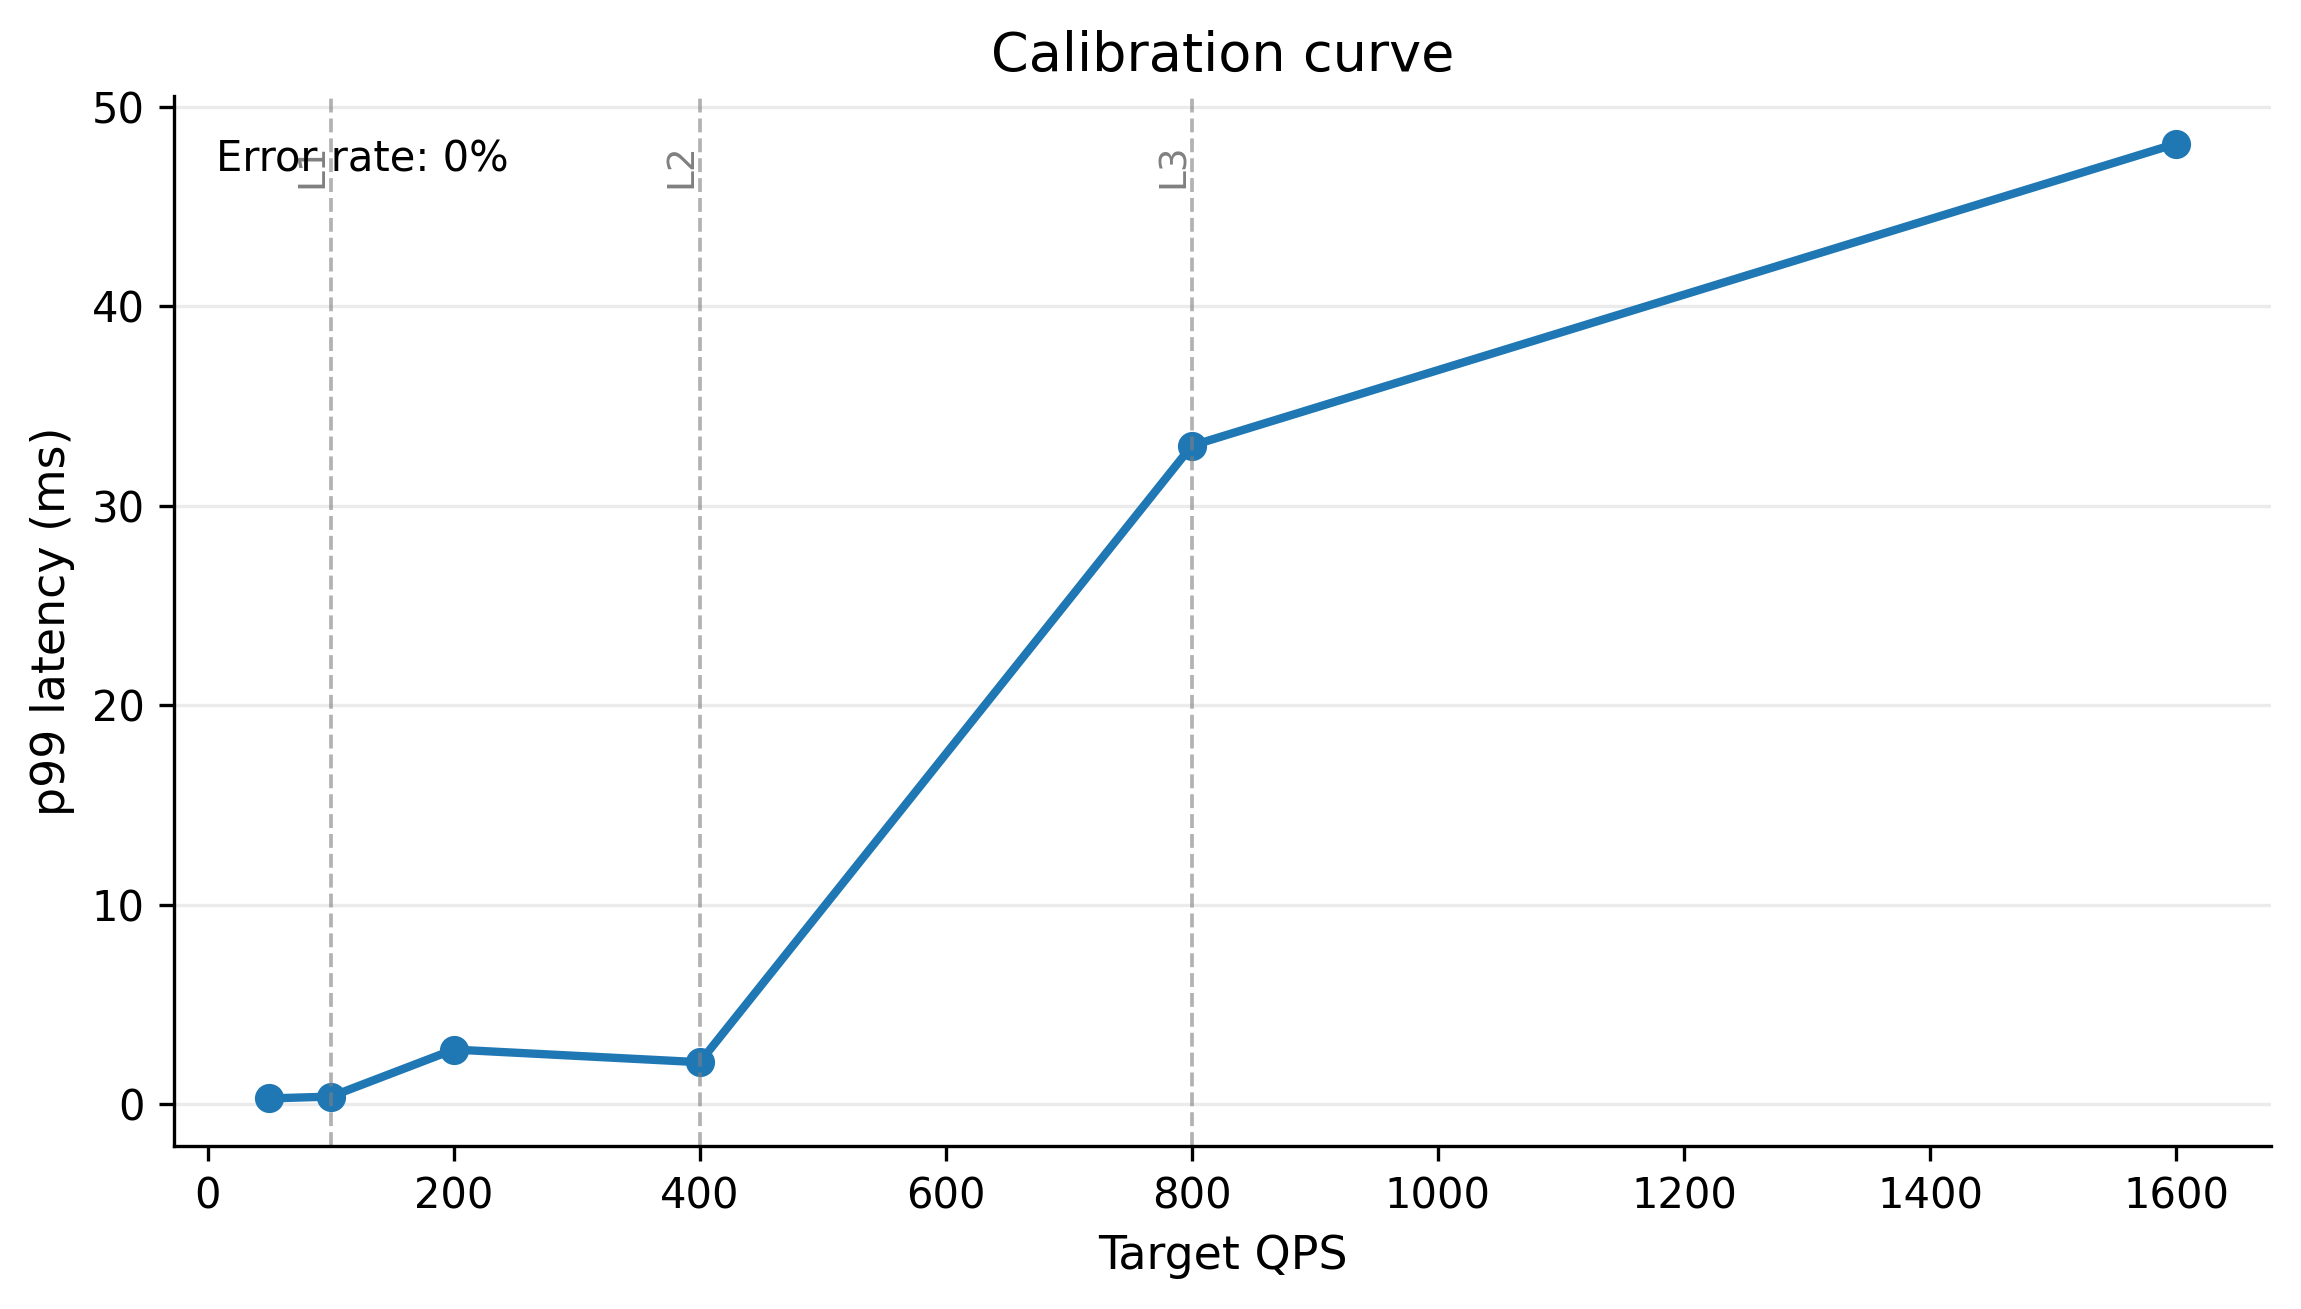

In [3]:
charts.chart_calibration_curve(REPO_ROOT, OUT_DIR)
show_fig("fig-calibration-curve")


## Figure: fig-s1-p99-vs-load

### Mục đích

Figure này tập trung vào tail latency của S1. S1 là steady-state workload (khối lượng công việc ở trạng thái ổn định), nên biểu đồ đường (line chart) theo các mức tải L1/L2/L3 là cách tiếp cận tự nhiên và dễ theo dõi nhất.

### Dữ liệu và cách đọc

- **Dữ liệu:** `comparison_AB.csv`, scenario S1, metric `p99_ms`.
- **Trục x:** Mức tải (load level).
- **Trục y:** p99 latency (ms).
- **Hai đường biểu diễn:** Mode A và Mode B.

### Điểm cần quan sát

- Mode B có giá trị trung bình (mean) p99 thấp hơn ở cả ba mức L1/L2/L3.
- Các mức L2 và L3 được đánh dấu là có ý nghĩa thống kê (significant) trong file CSV.
- Riêng mức L1, sự chênh lệch p99 chỉ nên được diễn giải như một xu hướng thay vì một kết luận khẳng định chắc chắn.

generated: D:\Project\NT531_EKS\NT531_EKS-Cilium-Kubeproxy-Benchmark\docs\figures\thesis\fig-s1-p99-vs-load.png
generated: D:\Project\NT531_EKS\NT531_EKS-Cilium-Kubeproxy-Benchmark\docs\figures\thesis\fig-s1-p99-vs-load.pdf


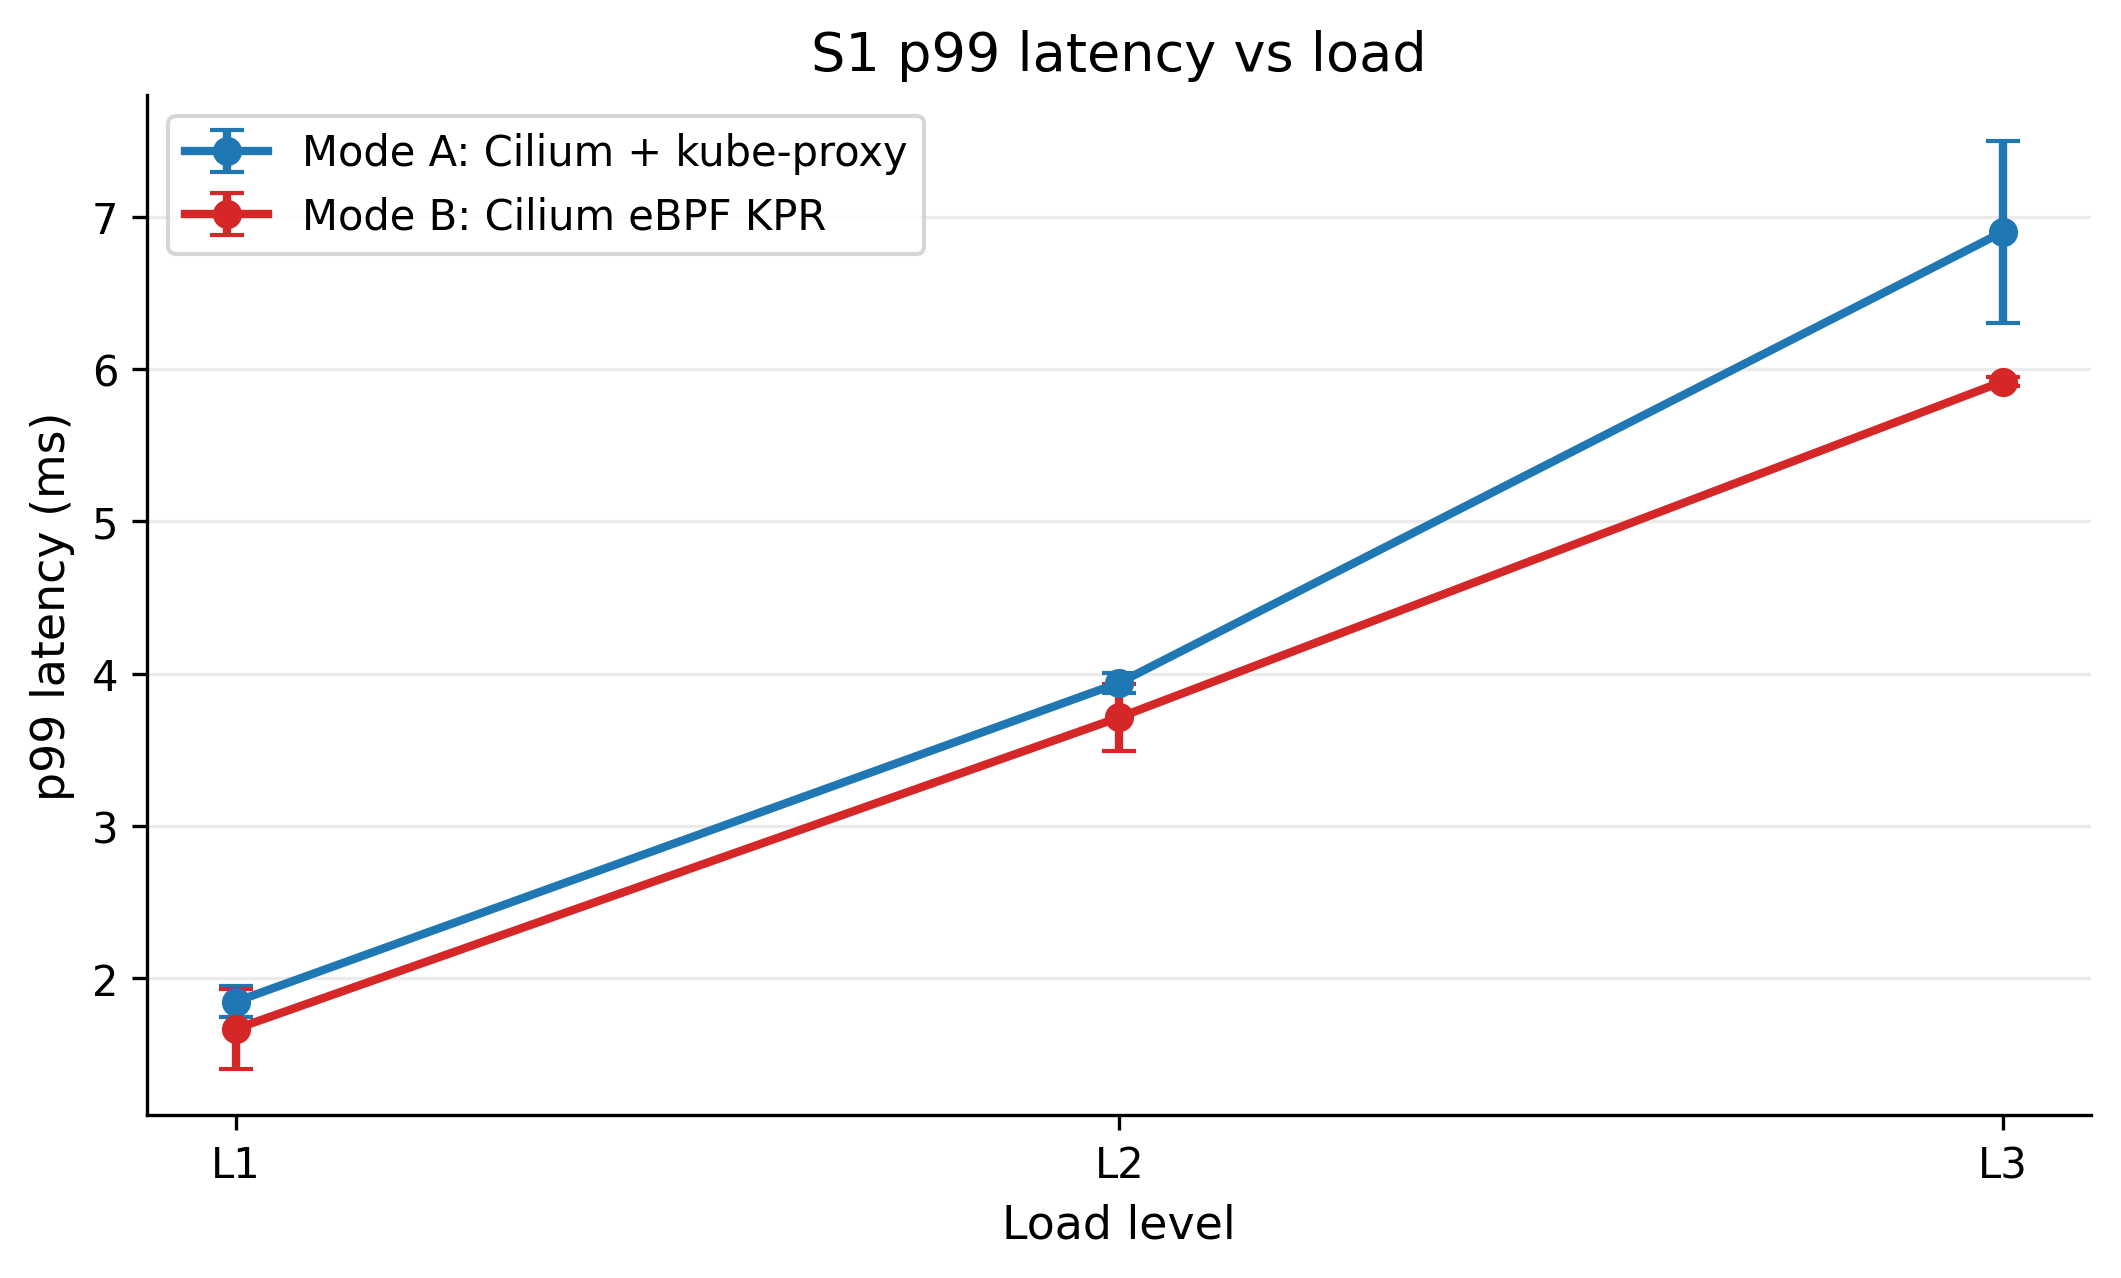

In [12]:
charts.chart_s1_p99_vs_load(comparison, OUT_DIR)
show_fig("fig-s1-p99-vs-load")


## Figure: fig-s1-latency-small-multiples

### Mục đích

Figure này tách p50, p90 và p99 thành các bảng (panel) riêng biệt để xem liệu xu hướng cải thiện có nhất quán trên nhiều phần của phân phối độ trễ (latency distribution) hay không.

### Dữ liệu và cách đọc

- **Dữ liệu:** `comparison_AB.csv`, scenario S1.
- **Metrics:** `p50_ms`, `p90_ms`, `p99_ms`.
- Mỗi bảng so sánh Mode A với Mode B theo các mức tải L1/L2/L3.

### Điểm cần quan sát

- Mode B nằm thấp hơn Mode A về giá trị trung bình (mean) trên cả ba biểu đồ p50/p90/p99.
- Ở mức tải L3, khoảng cách giữa hai mode trở nên rõ rệt hơn, đặc biệt là ở p90 và p99.
- Vẫn cần đối chiếu ý nghĩa thống kê (significance) riêng biệt cho từng loại metric và mức tải tương ứng.

generated: D:\Project\NT531_EKS\NT531_EKS-Cilium-Kubeproxy-Benchmark\docs\figures\thesis\fig-s1-latency-small-multiples.png
generated: D:\Project\NT531_EKS\NT531_EKS-Cilium-Kubeproxy-Benchmark\docs\figures\thesis\fig-s1-latency-small-multiples.pdf


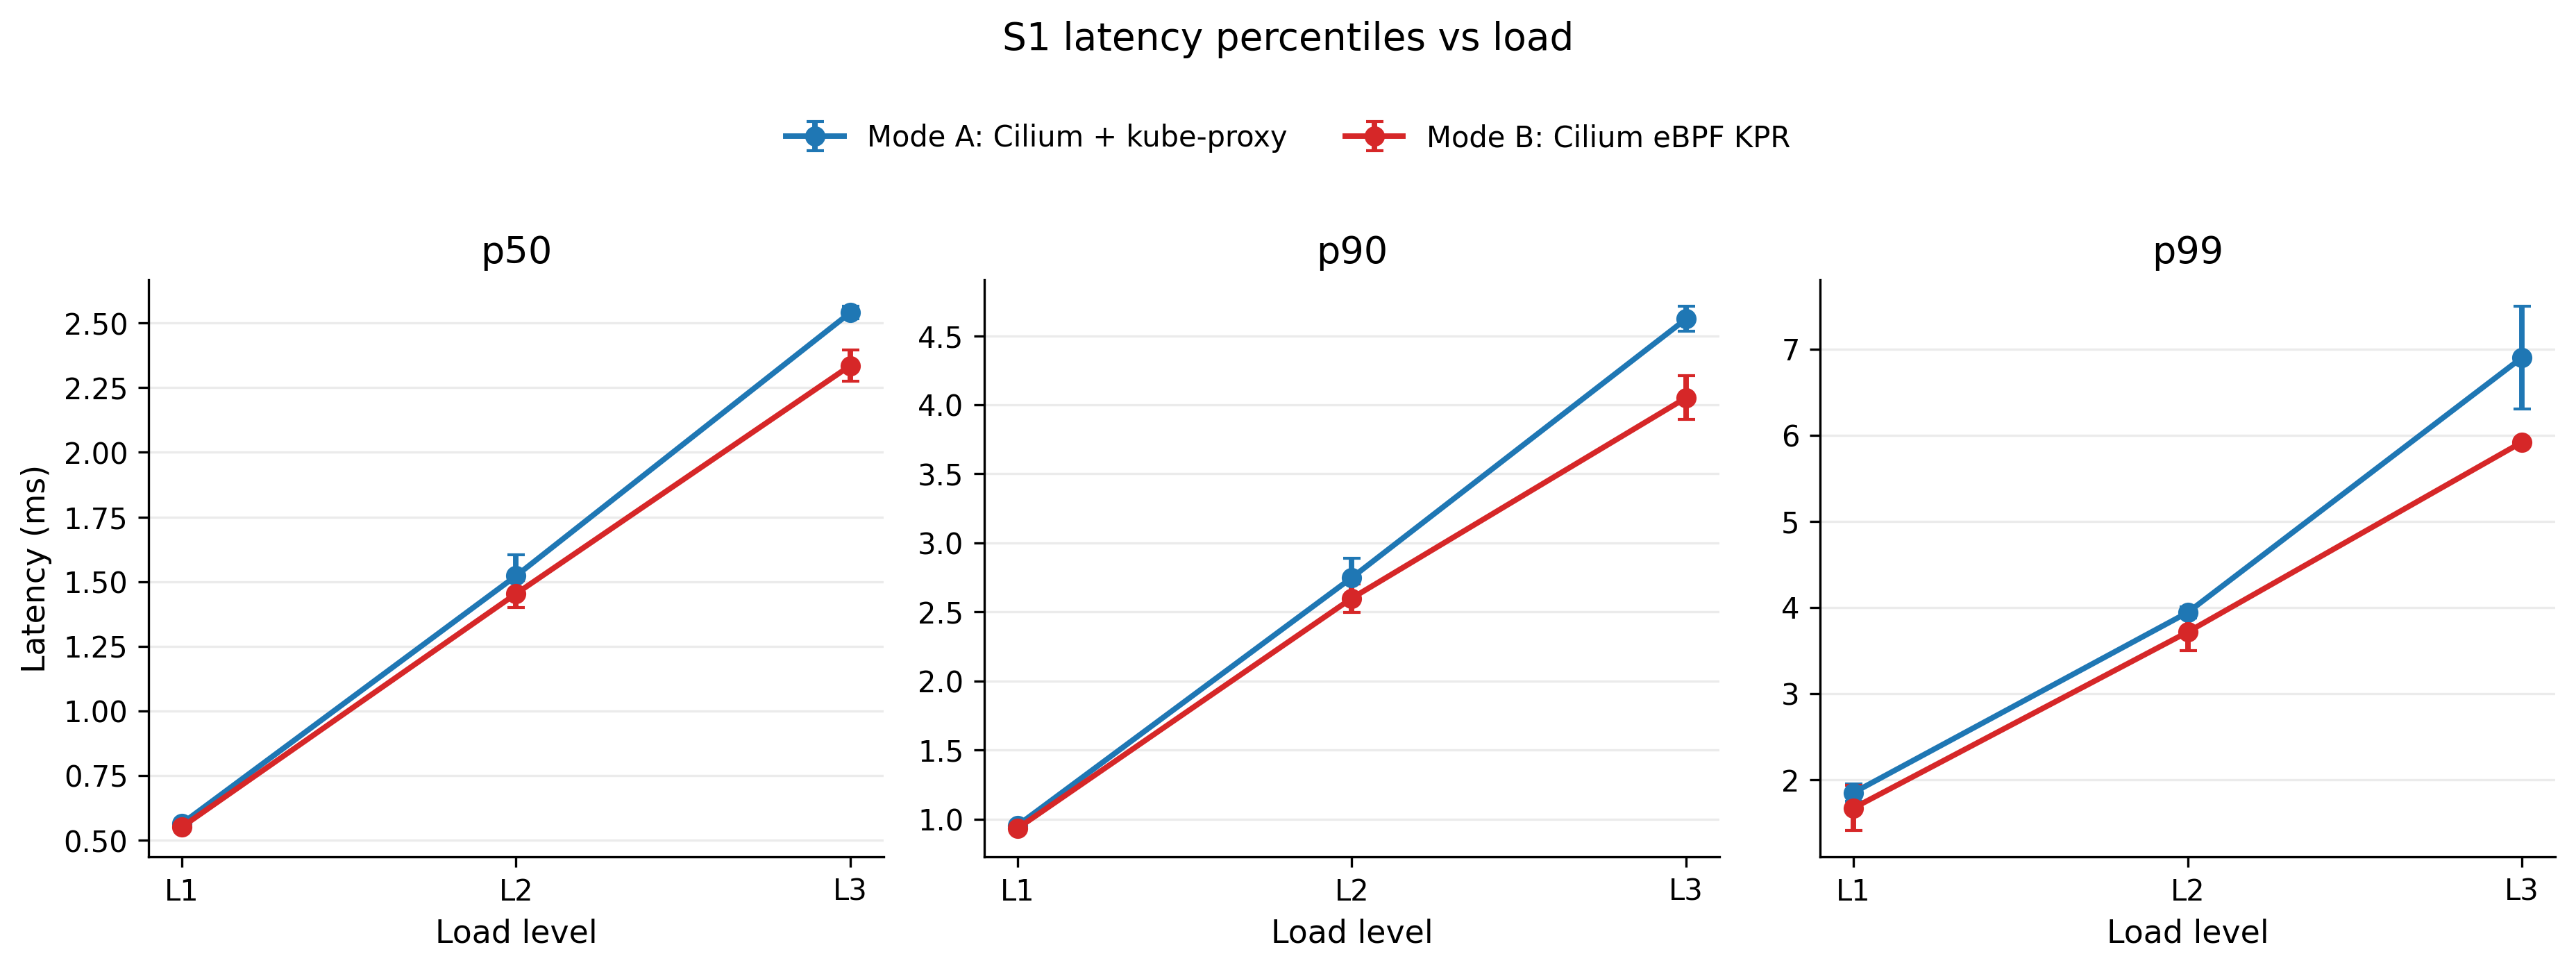

In [4]:
charts.chart_s1_latency_small_multiples(comparison, OUT_DIR)
show_fig("fig-s1-latency-small-multiples")


## Figure: fig-s1-delta-p99

### Mục đích

Figure này rút gọn kết quả S1 p99 thành phần trăm thay đổi (delta %) của Mode B so với Mode A. Đây là hình ảnh lý tưởng để sử dụng trong các slide thuyết trình vì giúp người xem nắm bắt hướng cải thiện cực kỳ nhanh chóng.

### Dữ liệu và cách đọc

- **Dữ liệu:** `comparison_AB.csv`, scenario S1, metric `p99_ms`.
- **Trục x:** Các mức tải L1/L2/L3.
- **Trục y:** Delta % (Phần trăm chênh lệch).
- **Giá trị âm:** Nghĩa là Mode B có p99 thấp hơn Mode A (cải thiện tốt hơn).
- **Dấu `*`:** Biểu thị kết quả có ý nghĩa thống kê (`significant == YES`).

### Điểm cần quan sát

- Tất cả các cột đều có giá trị âm, tuy nhiên mức L1 không có ý nghĩa thống kê (non-significant). 
- Các kết luận mạnh mẽ về hiệu năng nên tập trung chủ yếu vào hai mức tải L2 và L3, nơi sự cải thiện được xác nhận bởi kiểm định thống kê.

generated: D:\Project\NT531_EKS\NT531_EKS-Cilium-Kubeproxy-Benchmark\docs\figures\thesis\fig-s1-delta-p99.png
generated: D:\Project\NT531_EKS\NT531_EKS-Cilium-Kubeproxy-Benchmark\docs\figures\thesis\fig-s1-delta-p99.pdf


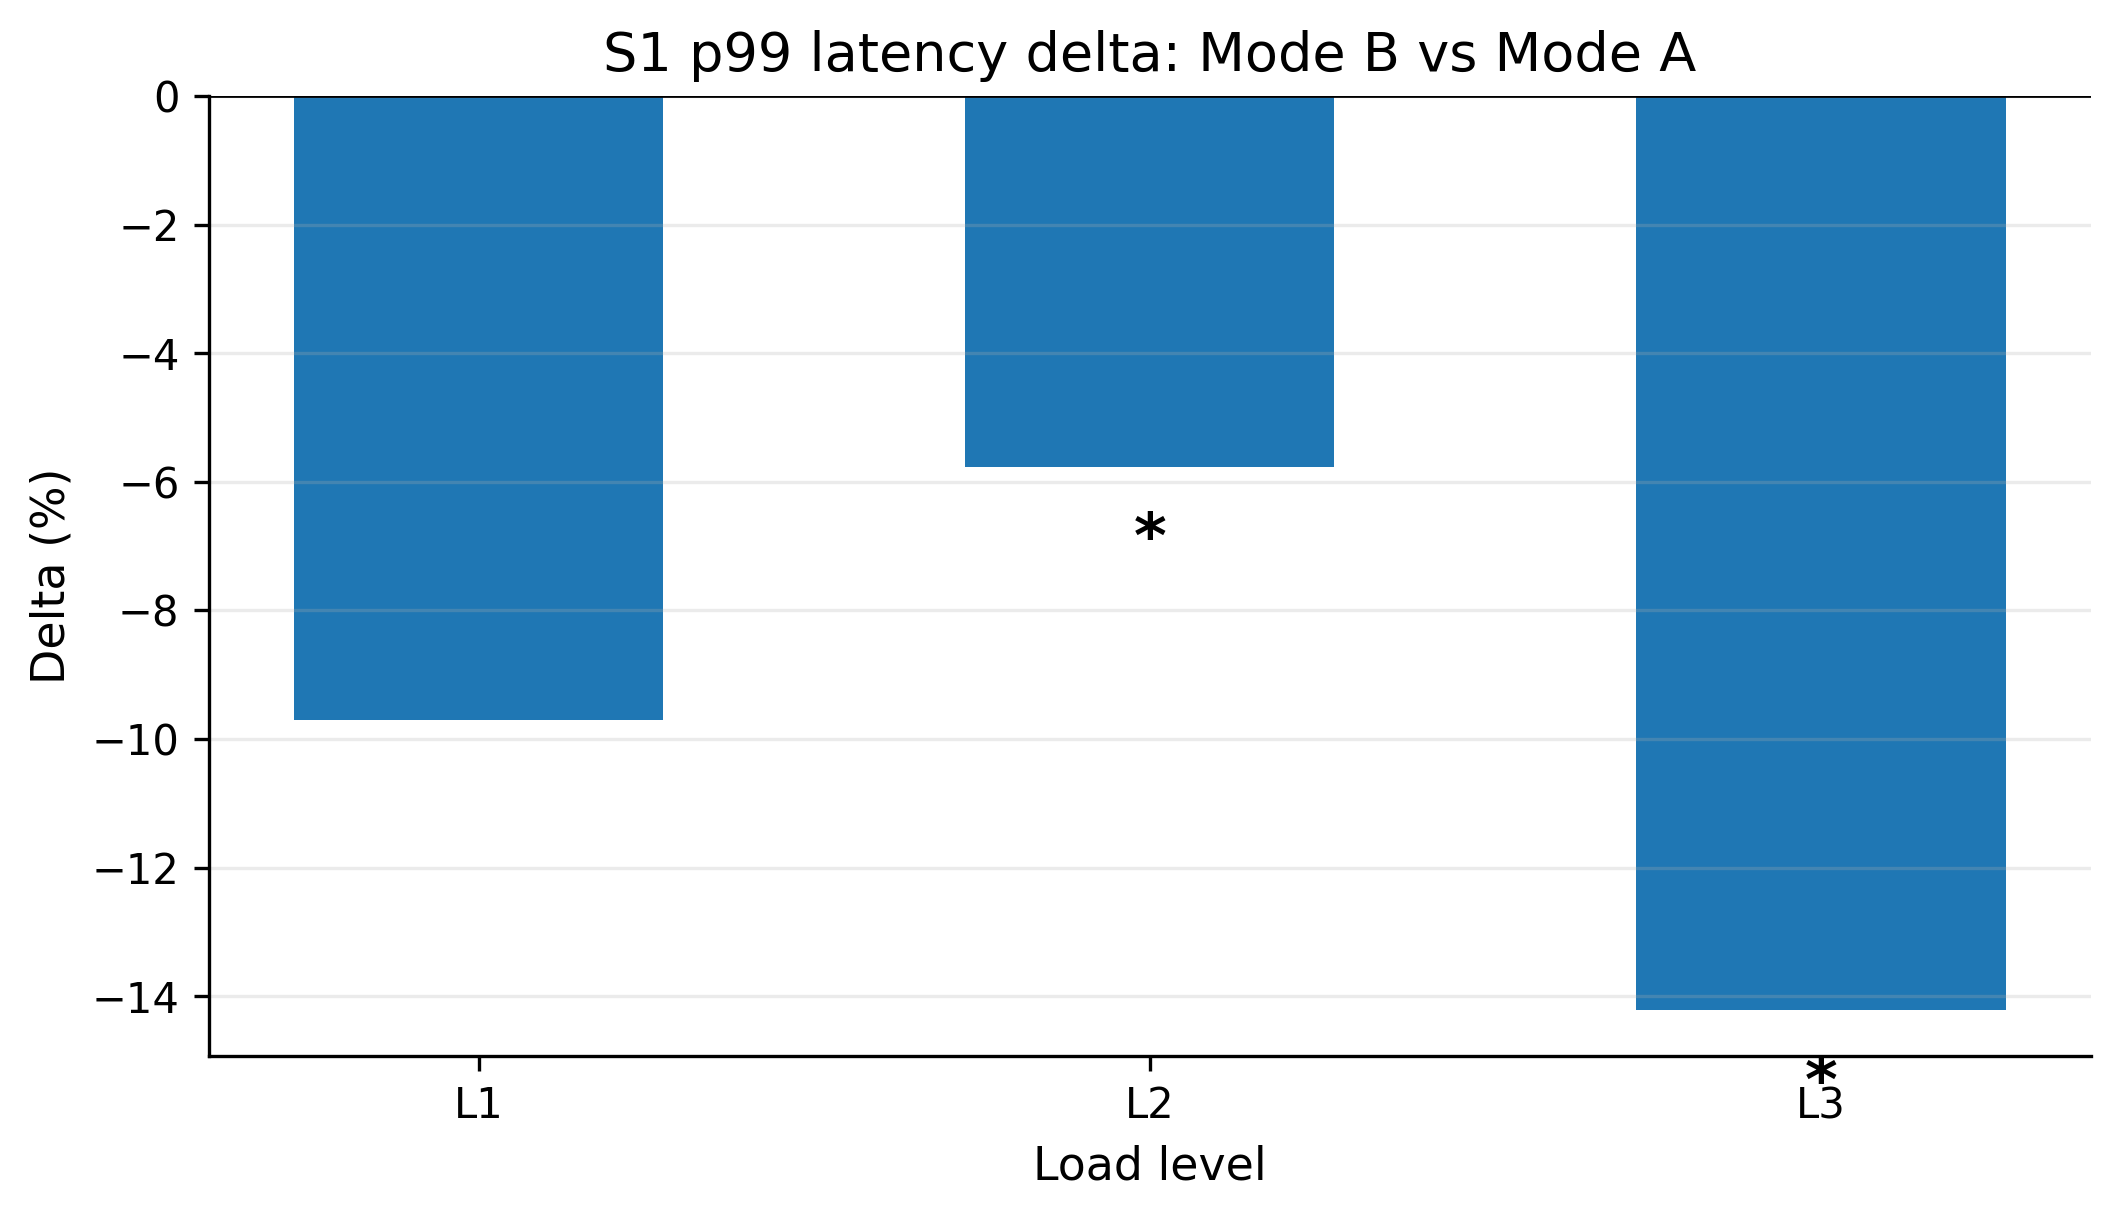

In [5]:
charts.chart_s1_delta_p99(comparison, OUT_DIR)
show_fig("fig-s1-delta-p99")


## Figure: fig-s2-phase-p99-l2

### Mục đích

Figure này phân tích kịch bản S2 ở mức tải L2 theo từng giai đoạn (phase). Vì S2 bao gồm các giai đoạn đặc thù như ramp-up, sustained, burst và cooldown, việc gộp chung dữ liệu thành một nhóm duy nhất sẽ làm mất đi các đặc tính quan trọng của khối lượng công việc.

### Dữ liệu và cách đọc

- **Dữ liệu:** `comparison_AB.csv`, scenario S2, mức tải L2, metric `p99_ms`.
- **Trục x:** Các giai đoạn của S2 (S2 phase).
- **Trục y:** p99 latency (ms).
- **Hai đường biểu diễn:** Mode A và Mode B.

### Các giai đoạn cần chú ý

- **Ramp-up:** Mode B có kết quả thấp hơn và có ý nghĩa thống kê (significant).
- **Sustained:** Mode B thấp hơn về giá trị trung bình nhưng không có ý nghĩa thống kê.
- **Burst 1:** Mode B cao hơn Mode A; đây là một điểm ngoại lệ (exception) cần được nêu rõ trong báo cáo.
- **Burst 2:** Khác biệt giữa hai mode gần như không đáng kể.
- **Burst 3:** Mode B thấp hơn về giá trị trung bình nhưng không có ý nghĩa thống kê.
- **Cooldown:** Mode B thấp hơn nhẹ so với Mode A.

generated: D:\Project\NT531_EKS\NT531_EKS-Cilium-Kubeproxy-Benchmark\docs\figures\thesis\fig-s2-phase-p99-l2.png
generated: D:\Project\NT531_EKS\NT531_EKS-Cilium-Kubeproxy-Benchmark\docs\figures\thesis\fig-s2-phase-p99-l2.pdf


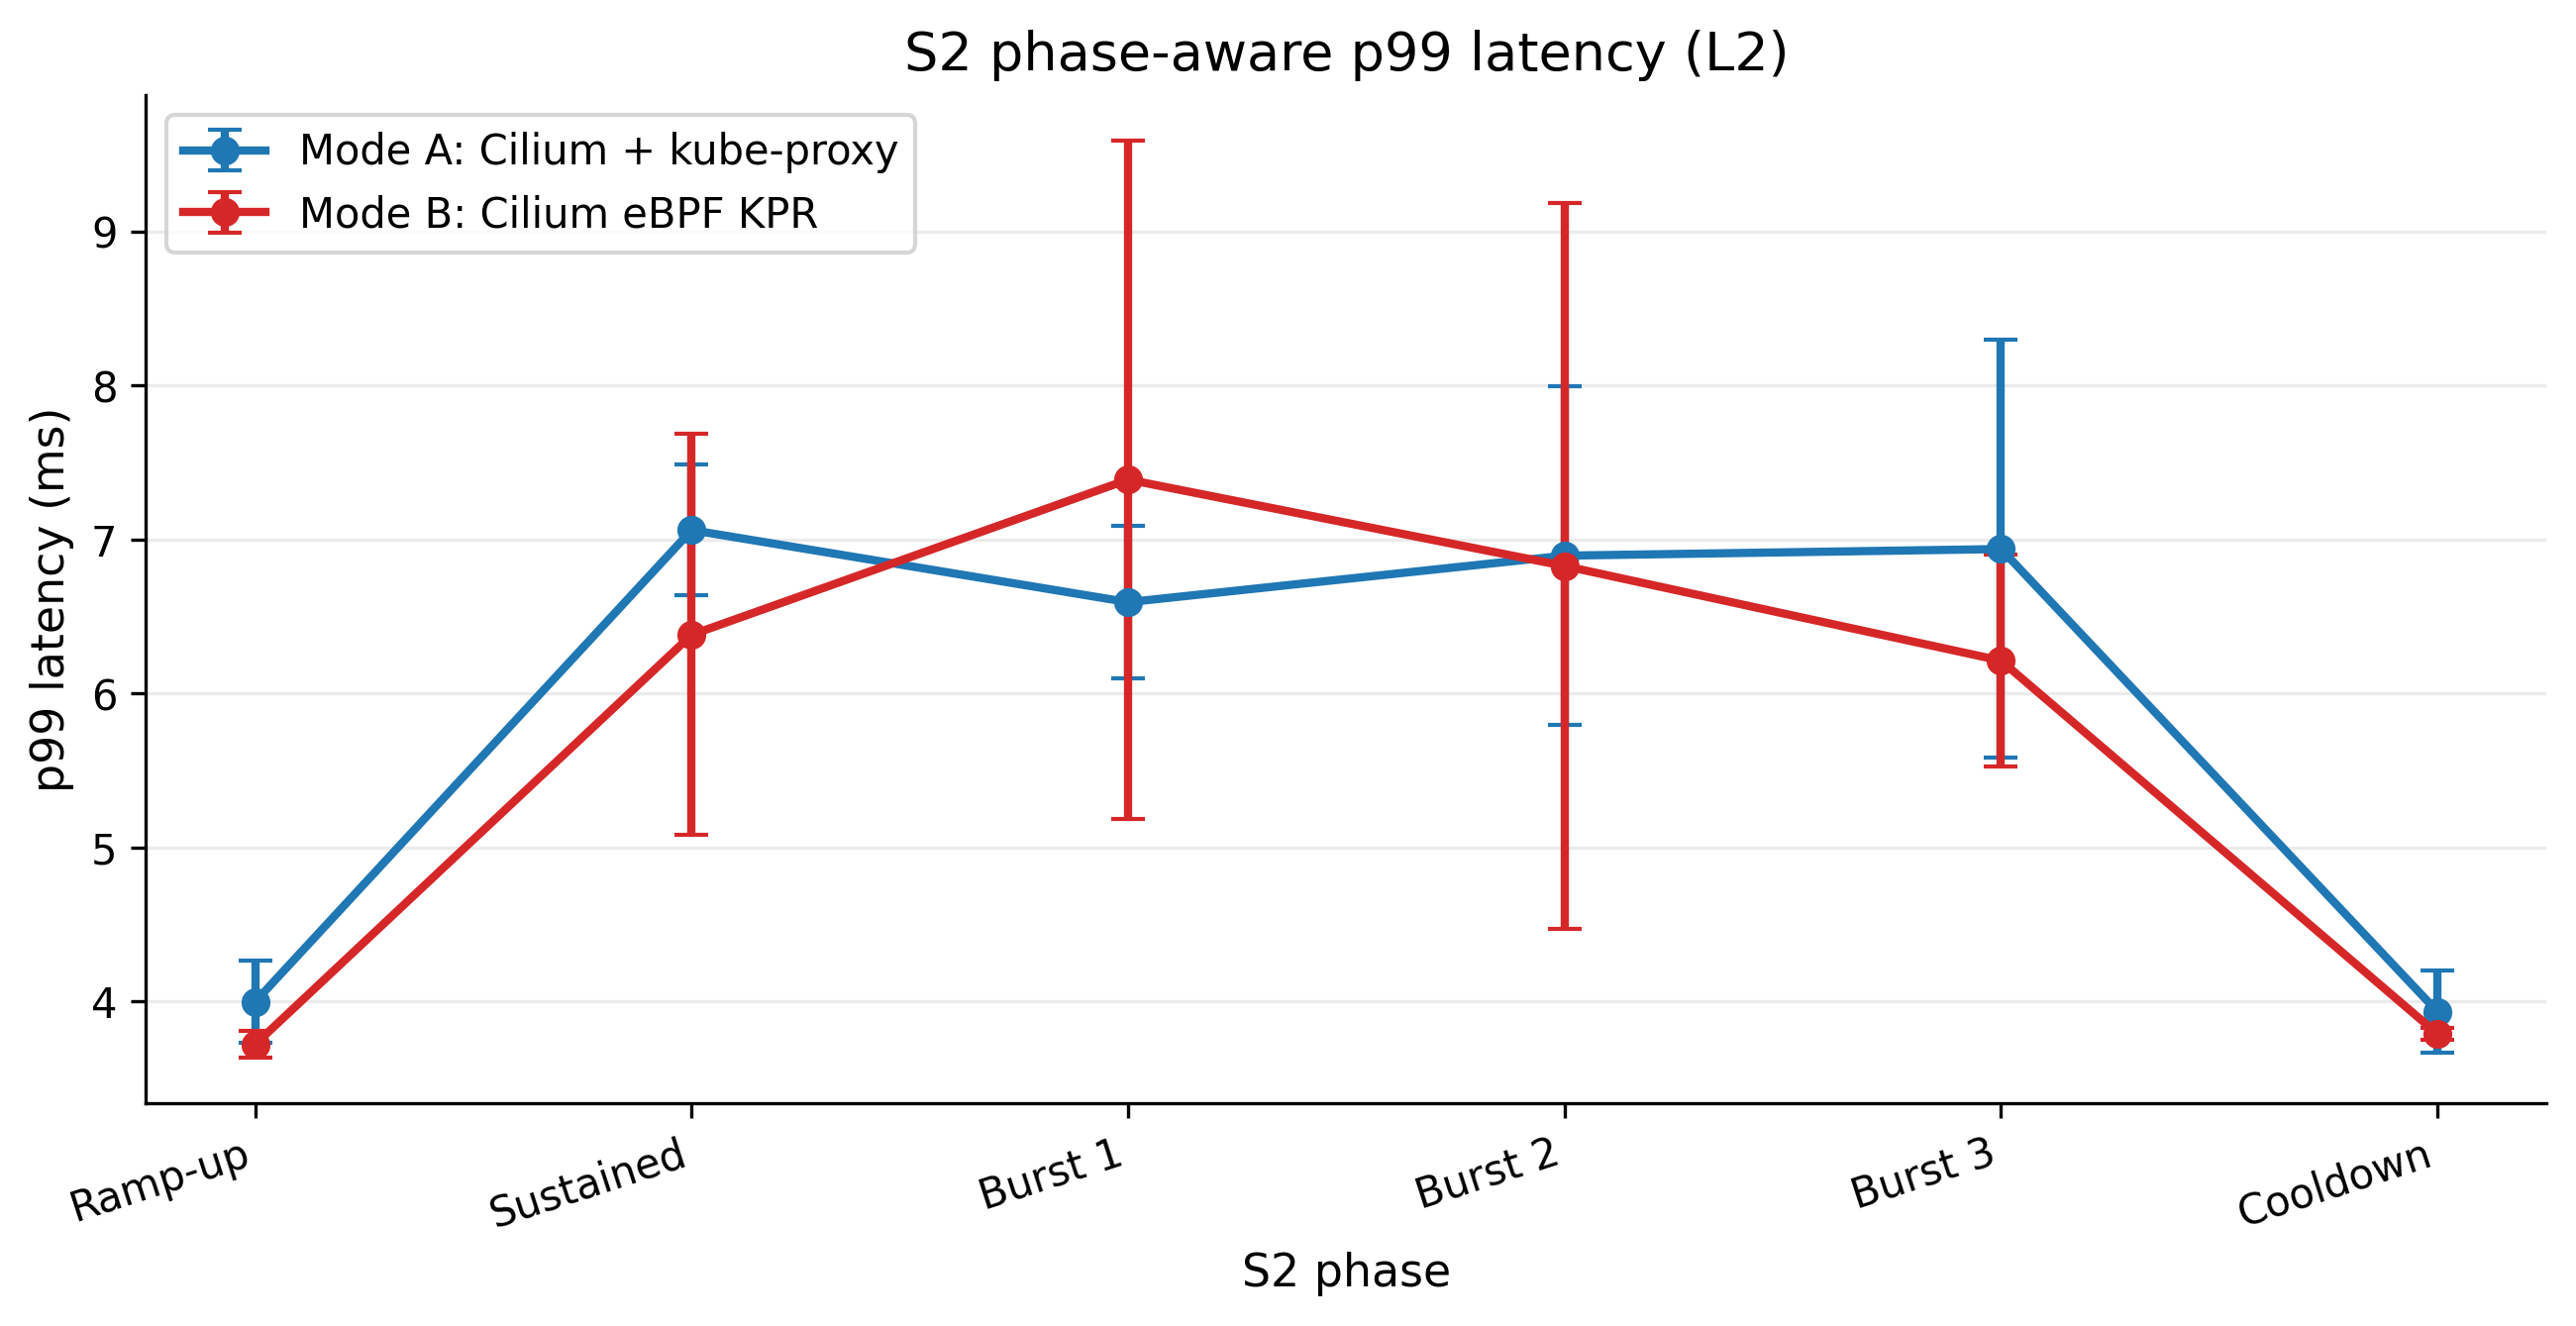

In [6]:
charts.chart_s2_phase_p99(comparison, OUT_DIR, "L2")
show_fig("fig-s2-phase-p99-l2")


## Figure: fig-s2-phase-p99-l3

### Mục đích

Figure này phân tích kịch bản S2 tại mức tải L3, nơi khối lượng công việc nặng hơn và các giai đoạn burst có thể làm lộ rõ sự khác biệt về tail latency (độ trễ đuôi) giữa hai mode.

### Dữ liệu và cách đọc

- **Dữ liệu:** `comparison_AB.csv`, scenario S2, mức tải L3, metric `p99_ms`.
- **Trục x:** Các giai đoạn của S2 (S2 phase).
- **Trục y:** p99 latency (ms).
- **Hai đường biểu diễn:** Mode A và Mode B.

### Các giai đoạn cần chú ý

- Mode B có giá trị p99 trung bình (mean) thấp hơn Mode A ở tất cả các giai đoạn của mức tải L3.
- Các giai đoạn **Burst 1, Burst 2, Burst 3** và **Cooldown** cho thấy mức giảm (delta âm) lớn hơn so với các giai đoạn khác.
- Tuy nhiên, do các giai đoạn ở mức L3 không được đánh dấu là có ý nghĩa thống kê (significant), kết quả này nên được diễn giải là **xu hướng về giá trị trung bình**, không phải là kết luận thống kê tuyệt đối.

generated: D:\Project\NT531_EKS\NT531_EKS-Cilium-Kubeproxy-Benchmark\docs\figures\thesis\fig-s2-phase-p99-l3.png
generated: D:\Project\NT531_EKS\NT531_EKS-Cilium-Kubeproxy-Benchmark\docs\figures\thesis\fig-s2-phase-p99-l3.pdf


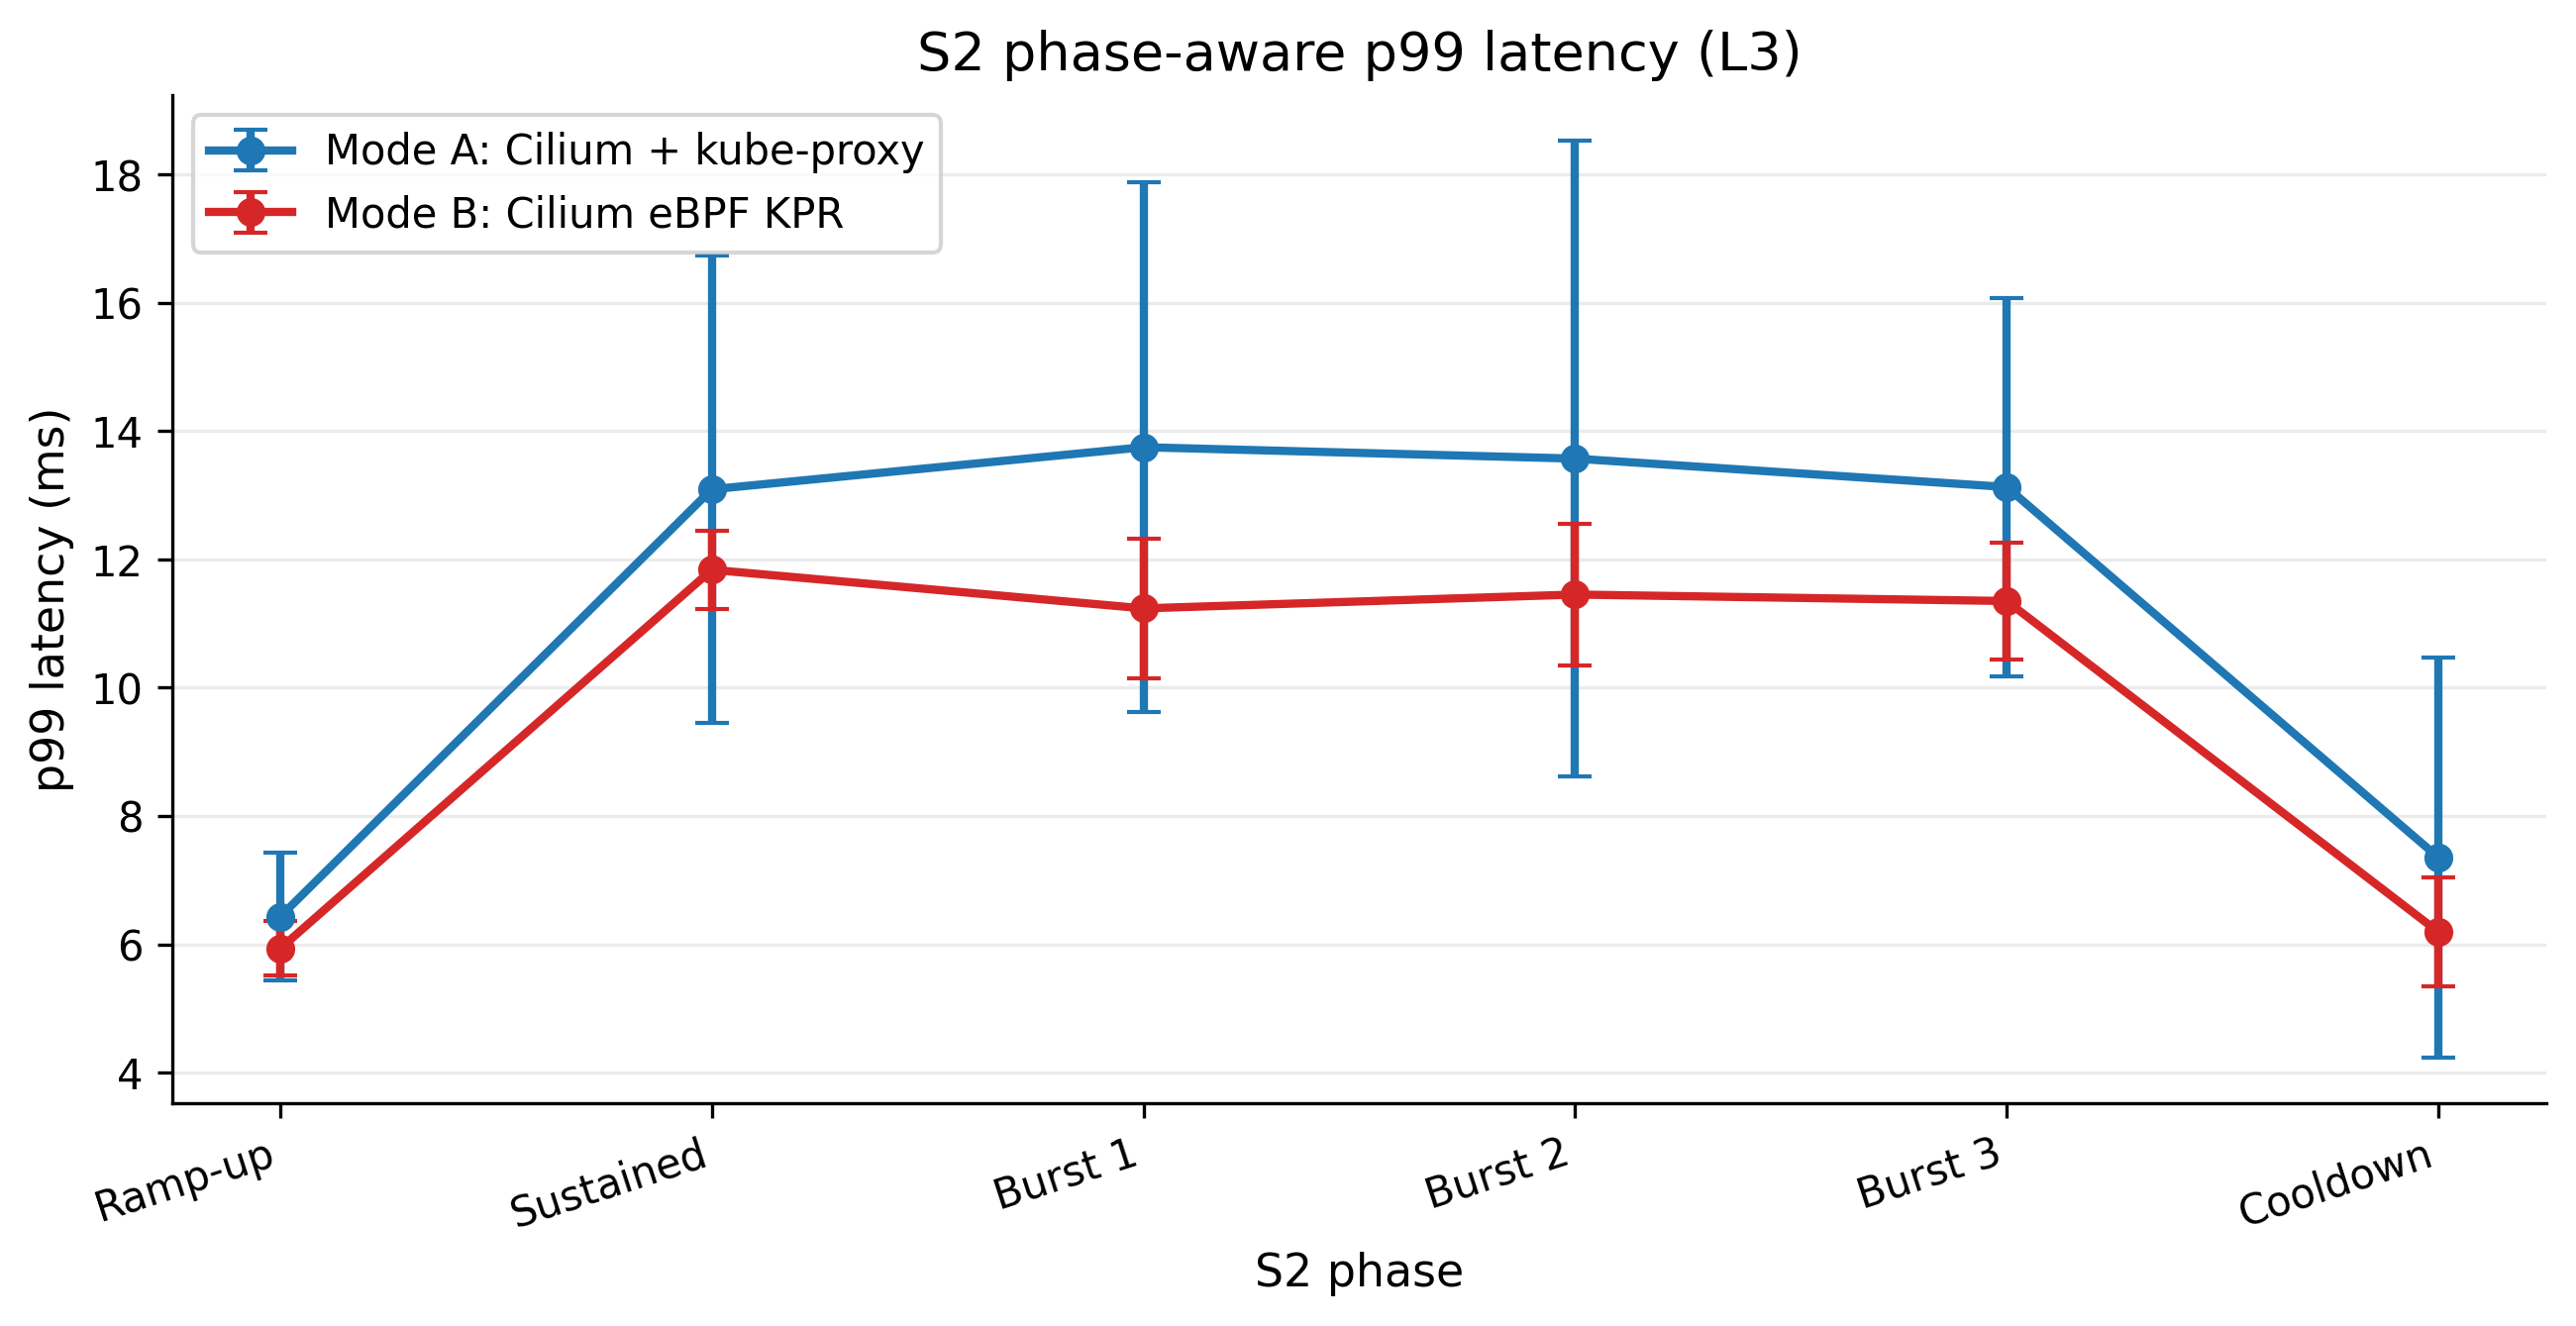

In [7]:
charts.chart_s2_phase_p99(comparison, OUT_DIR, "L3")
show_fig("fig-s2-phase-p99-l3")


## Figure: fig-s2-p99-delta-heatmap

### Mục đích

Heatmap này giúp trả lời nhanh câu hỏi: Mode B tốt hơn hay kém hơn Mode A ở giai đoạn (phase) nào và mức tải (load) nào trong kịch bản S2.

### Dữ liệu và cách đọc

- **Dữ liệu:** Các file raw final `fortio_phase*.json` của kịch bản S2.
- **Hàng:** Các giai đoạn của S2 (S2 phase).
- **Cột:** Các mức tải L2 và L3.
- **Ô dữ liệu:** Phần trăm thay đổi (delta %) của p99 từ Mode B so với Mode A.
- **Màu sắc:** Giá trị âm (thường là màu xanh/lạnh) nghĩa là Mode B có p99 thấp hơn; giá trị dương (thường là màu đỏ/nóng) nghĩa là Mode B có p99 cao hơn.

### Điểm cần quan sát

- Ở mức tải **L3**, tất cả các ô đều mang giá trị âm, đặc biệt là ở các giai đoạn burst và cooldown.
- Ở mức tải **L2**, giai đoạn **Burst 1** là một ngoại lệ với giá trị dương (+12.1%).
- Giai đoạn **Burst 2** ở mức L2 gần như không có sự khác biệt giữa hai mode.
- **Lưu ý:** Không diễn giải màu sắc của heatmap như bằng chứng về ý nghĩa thống kê (significance); heatmap chỉ phản ánh độ lớn của sự thay đổi.

generated: D:\Project\NT531_EKS\NT531_EKS-Cilium-Kubeproxy-Benchmark\docs\figures\thesis\fig-s2-p99-delta-heatmap.png
generated: D:\Project\NT531_EKS\NT531_EKS-Cilium-Kubeproxy-Benchmark\docs\figures\thesis\fig-s2-p99-delta-heatmap.pdf


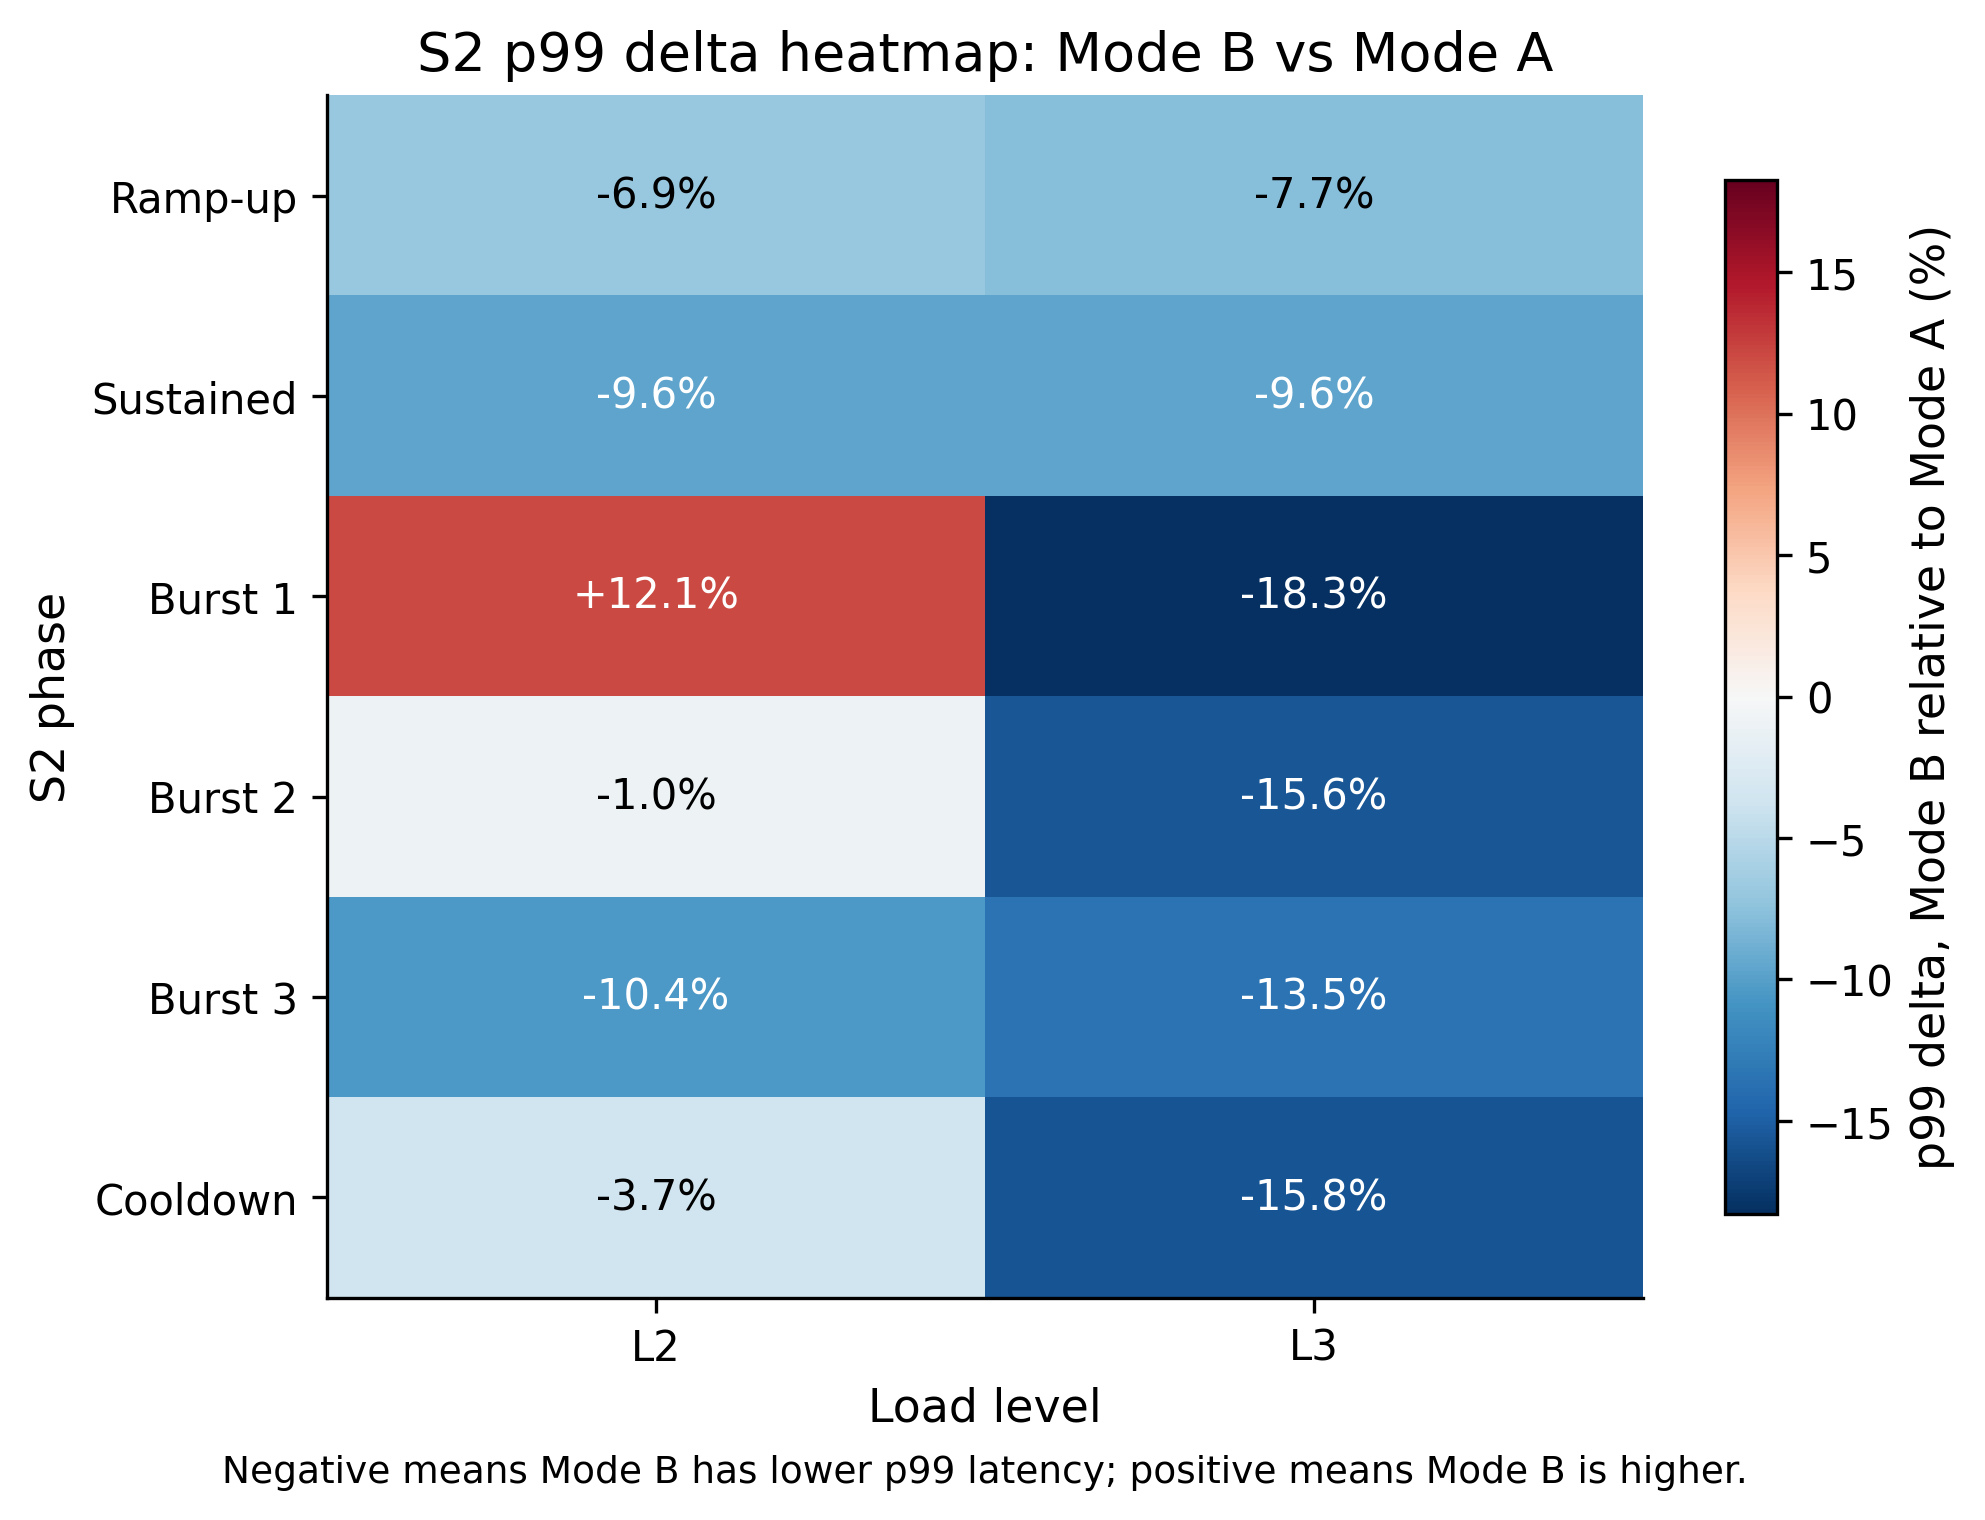

In [8]:
charts.chart_s2_p99_delta_heatmap(REPO_ROOT, OUT_DIR)
show_fig("fig-s2-p99-delta-heatmap")


## Figure: fig-repeatability-p99-dotplot

### Mục đích

Figure này cho thấy độ ổn định của benchmark qua các lần chạy thực tế (raw runs). Nó bổ sung cho các hình biểu diễn giá trị trung bình (mean) và khoảng tin cậy (CI) bằng cách hiển thị vị trí cụ thể của từng lần chạy đơn lẻ.

### Dữ liệu và cách đọc

- **Dữ liệu:** Các tệp raw final Fortio JSON.
- **Mỗi điểm (dot):** Đại diện cho một lần chạy thực tế (raw run).
- **Vạch ngang ngắn:** Biểu thị giá trị trung bình (mean) của nhóm.
- **Lưu ý:** Không sử dụng boxplot vì mỗi nhóm chỉ có số lượng mẫu nhỏ (n=3).

### Điểm cần quan sát

- Trong các kịch bản **S1 L3 Mode B** và **S3 L3 Policy OFF/ON**, các điểm dữ liệu nằm gần nhau, cho thấy hệ số biến thiên (CV) thấp và độ lặp lại cao.
- Kịch bản **S2** có sự biến động cao hơn giữa các lần chạy, đặc biệt là ở các giai đoạn burst và cooldown.
- Sự phân tán này giải thích lý do tại sao kịch bản S2 cần được phân tích chi tiết theo từng giai đoạn (phase-aware) và cần sử dụng từ ngữ thận trọng khi đưa ra kết luận.

generated: D:\Project\NT531_EKS\NT531_EKS-Cilium-Kubeproxy-Benchmark\results_analysis\repeatability_summary.csv
generated: D:\Project\NT531_EKS\NT531_EKS-Cilium-Kubeproxy-Benchmark\docs\figures\thesis\fig-repeatability-p99-dotplot.png
generated: D:\Project\NT531_EKS\NT531_EKS-Cilium-Kubeproxy-Benchmark\docs\figures\thesis\fig-repeatability-p99-dotplot.pdf


,scenario,load,phase,mode,policy_state,group_label,mean_p99_ms,stdev_p99_ms,cv_pct,n
24,S2,L3,phase4_cooldown,Mode A,,S2 L3 Cooldown - Mode A,7.355,1.257,17.092,3
20,S2,L3,phase3_burst2,Mode A,,S2 L3 Burst 2 - Mode A,13.572,1.995,14.702,3
9,S2,L2,phase3_burst2,Mode B,,S2 L2 Burst 2 - Mode B,6.828,0.949,13.896,3
18,S2,L3,phase3_burst1,Mode A,,S2 L3 Burst 1 - Mode A,13.750,1.662,12.089,3
7,S2,L2,phase3_burst1,Mode B,,S2 L2 Burst 1 - Mode B,7.389,0.886,11.996,3
16,S2,L3,phase2_sustained,Mode A,,S2 L3 Sustained - Mode A,13.094,1.468,11.207,3
22,S2,L3,phase3_burst3,Mode A,,S2 L3 Burst 3 - Mode A,13.129,1.187,9.038,3
5,S2,L2,phase2_sustained,Mode B,,S2 L2 Sustained - Mode B,6.381,0.524,8.218,3
10,S2,L2,phase3_burst3,Mode A,,S2 L2 Burst 3 - Mode A,6.938,0.546,7.873,3
8,S2,L2,phase3_burst2,Mode A,,S2 L2 Burst 2 - Mode A,6.895,0.443,6.420,3


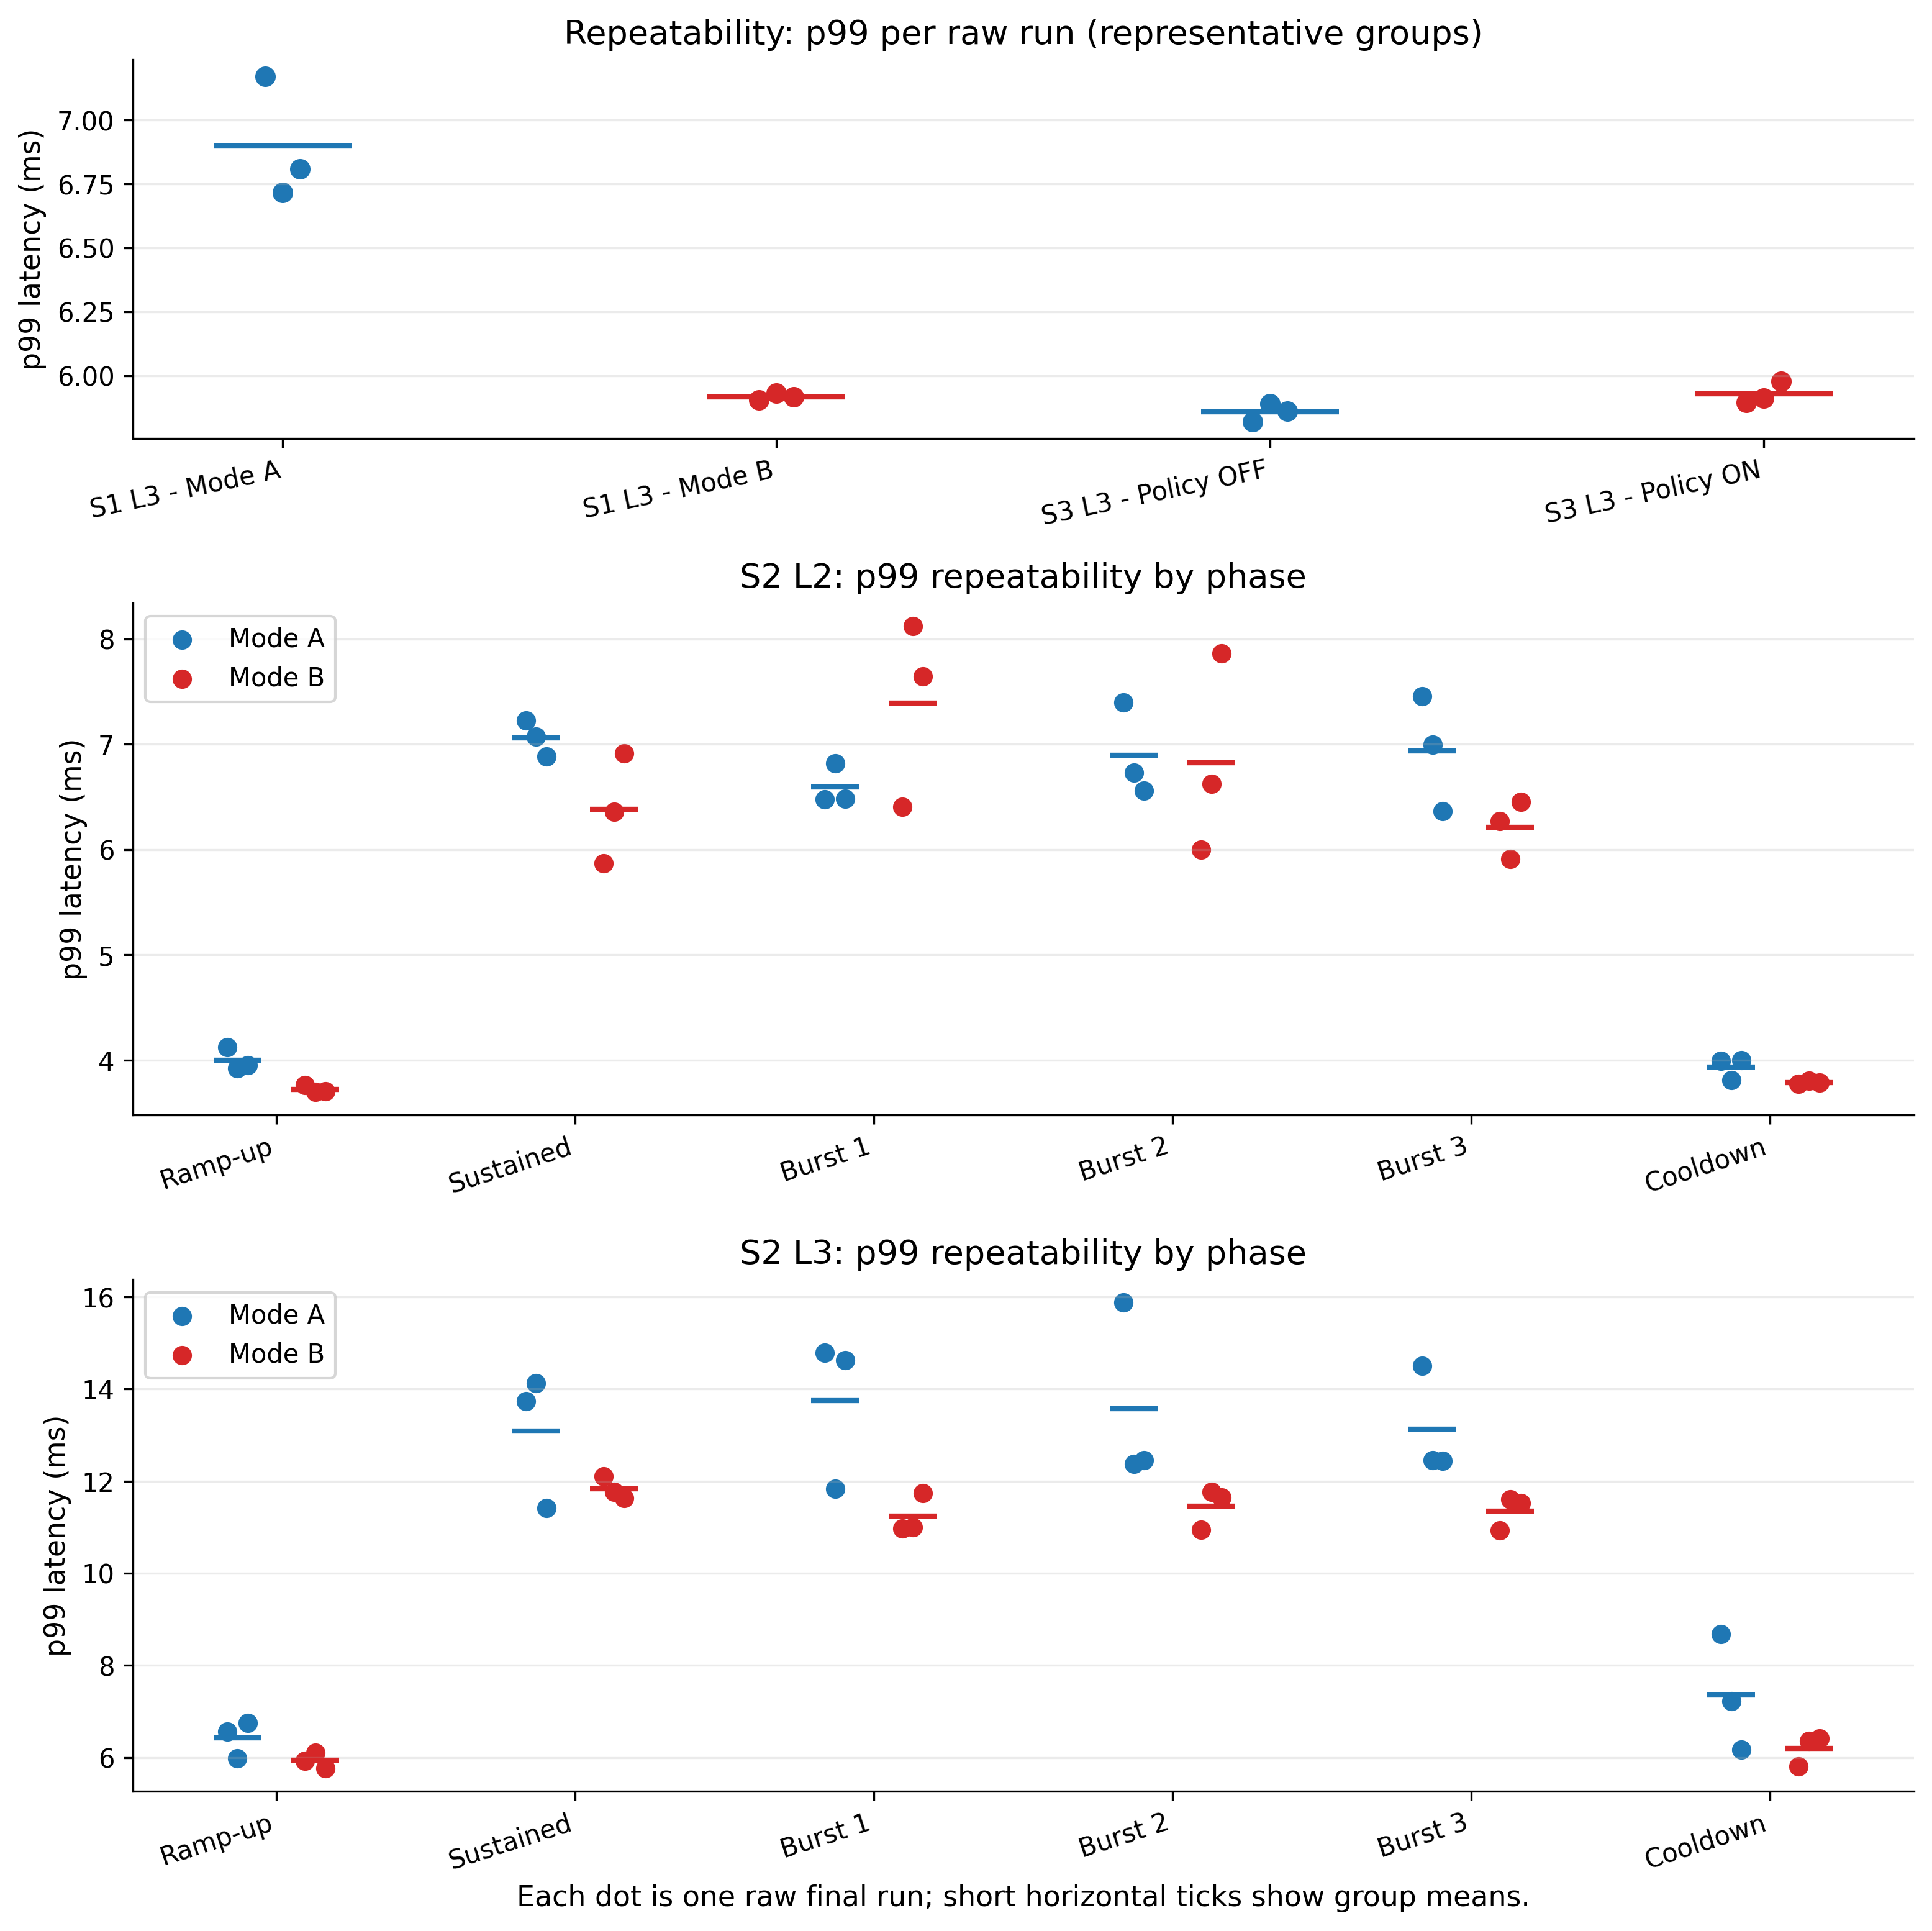

In [9]:
charts.write_repeatability_summary(repeatability_raw, ANALYSIS_DIR)
charts.chart_repeatability_p99_dotplot(repeatability_raw, OUT_DIR)
display(repeatability_summary.sort_values("cv_pct", ascending=False).head(10))
show_fig("fig-repeatability-p99-dotplot")


## Figure: fig-s3-policy-overhead-p99

### Mục đích

Figure này là hình ảnh trọng tâm của kịch bản S3. Nó đo lường mức độ ảnh hưởng của chính sách (policy overhead) bằng cách so sánh giữa Mode B khi tắt chính sách (Policy OFF) và khi bật chính sách (Policy ON), thay vì so sánh giữa Mode A và Mode B.

### Dữ liệu và cách đọc

- **Dữ liệu:** `aggregated_summary.csv`, các nhóm kết quả cuối cùng của S3.
- **Trục x:** Các mức tải L2/L3.
- **Trục y:** p99 latency (ms).
- **Ký hiệu (Marker):** Phân biệt giữa Policy OFF và Policy ON.

### Điểm cần quan sát

- Ở mức tải **L2**, Policy ON thấp hơn Policy OFF một chút; ở mức **L3**, Policy ON lại cao hơn Policy OFF nhẹ.
- Do khoảng tin cậy (CI) chồng lấn đáng kể và giá trị chênh lệch (delta) rất nhỏ, kết luận an toàn nhất là: các chính sách đơn giản không tạo ra overhead p99 đáng kể trong bộ dữ liệu (dataset) này.

generated: D:\Project\NT531_EKS\NT531_EKS-Cilium-Kubeproxy-Benchmark\docs\figures\thesis\fig-s3-policy-overhead-p99.png
generated: D:\Project\NT531_EKS\NT531_EKS-Cilium-Kubeproxy-Benchmark\docs\figures\thesis\fig-s3-policy-overhead-p99.pdf


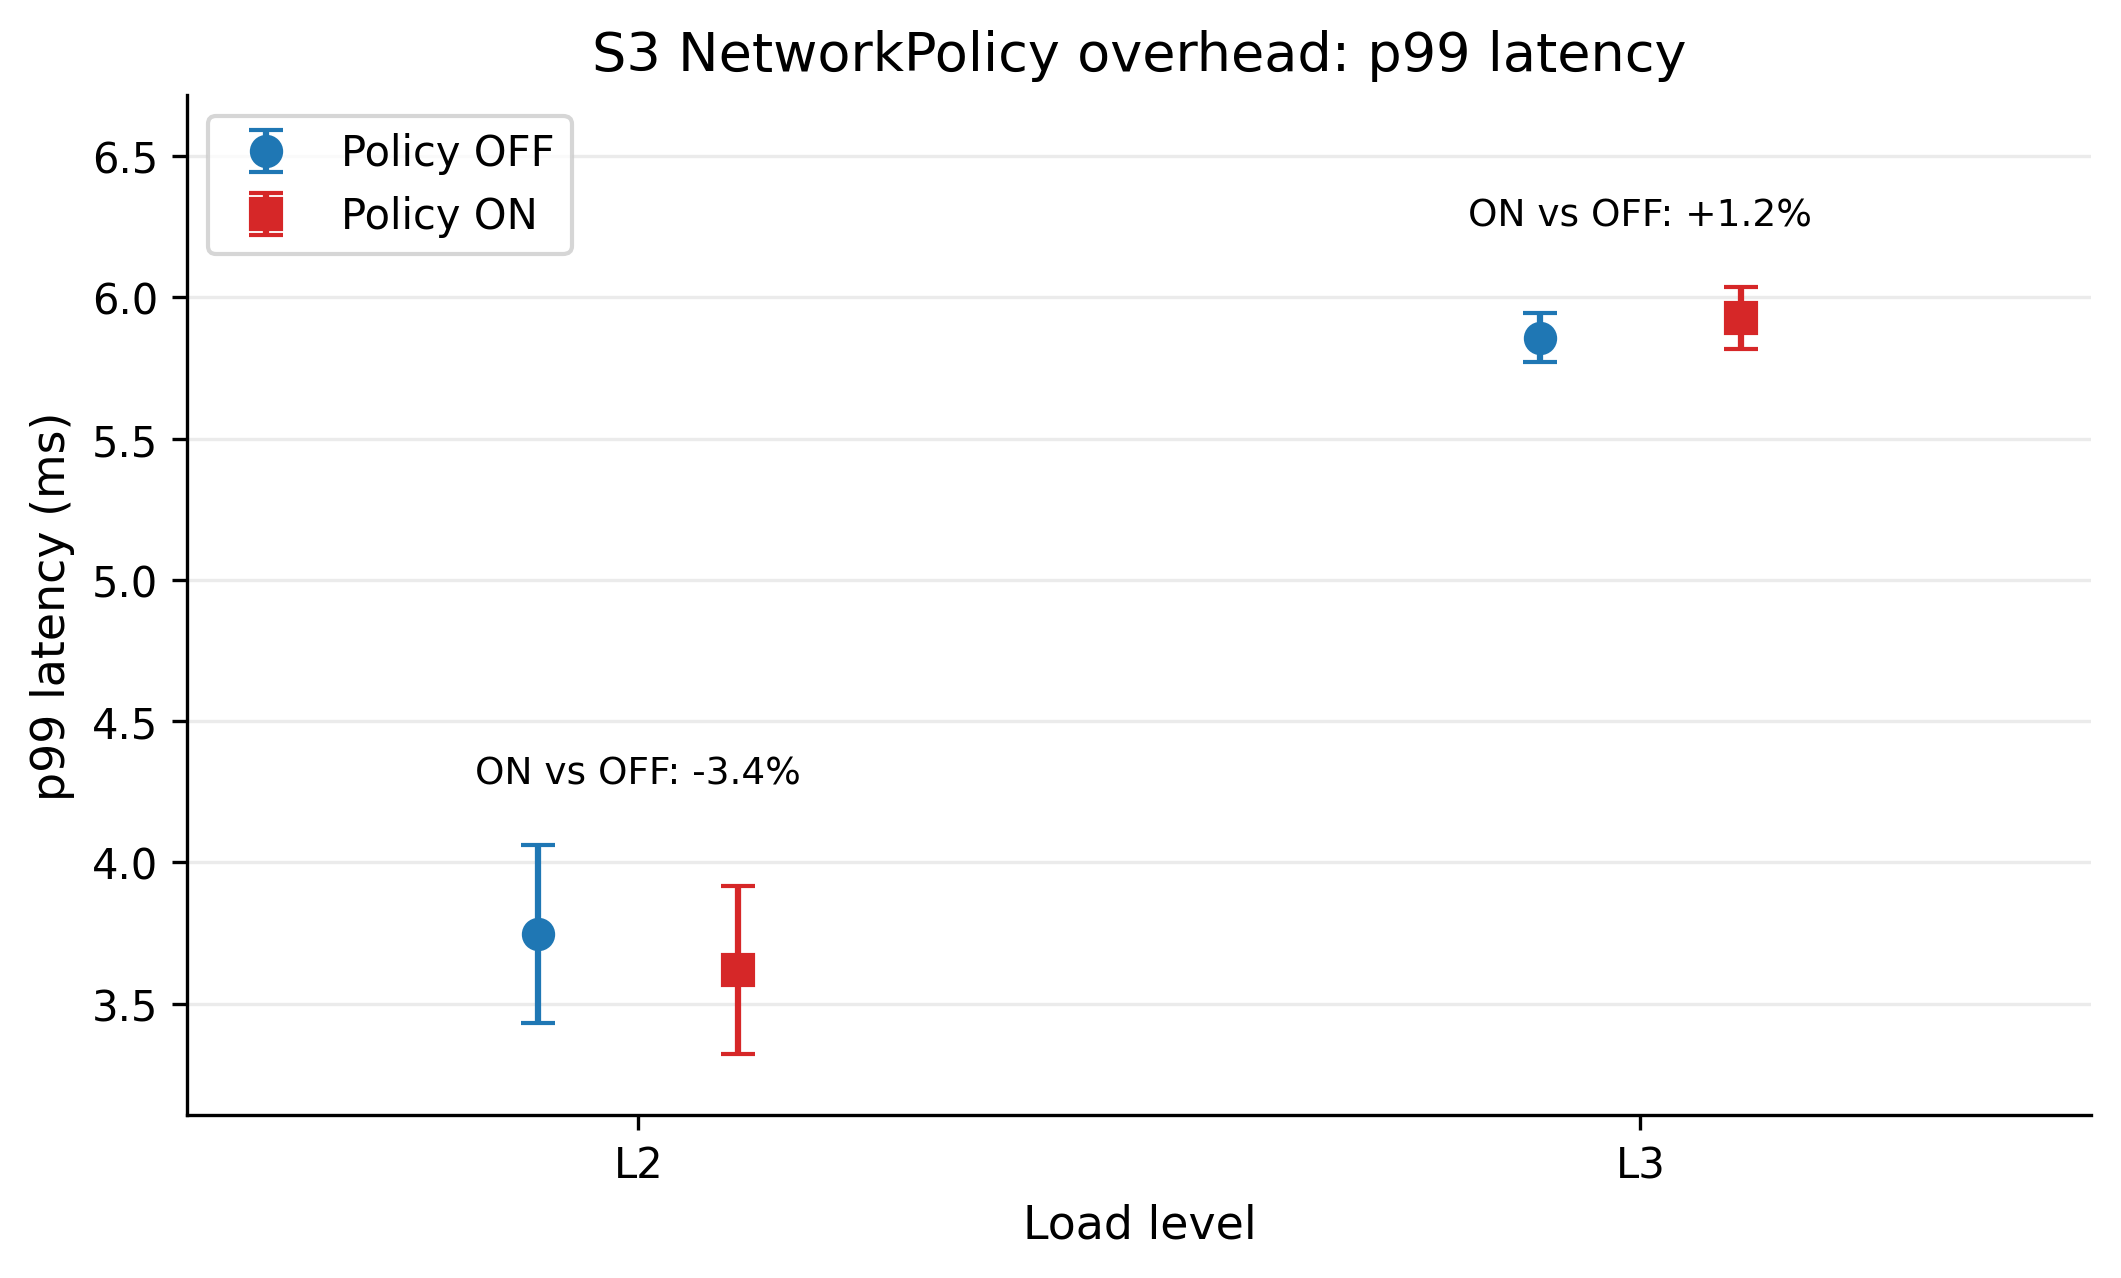

In [10]:
charts.chart_s3_policy_p99(aggregated, OUT_DIR)
show_fig("fig-s3-policy-overhead-p99")


## Figure: fig-s3-policy-overhead-rps

### Mục đích

Figure này đóng vai trò là bằng chứng hỗ trợ (supporting evidence) cho kịch bản S3: kiểm tra xem việc bật chính sách (Policy ON) có làm sụt giảm lượng yêu cầu xử lý thực tế (achieved RPS) hay không.

### Dữ liệu và cách đọc

- **Dữ liệu:** `aggregated_summary.csv`, các nhóm kết quả cuối cùng của S3.
- **Trình bày:** Sử dụng các bảng (panel) riêng biệt cho L2 và L3 vì giá trị giữa OFF và ON gần như trùng khít nhau.
- **Trục y:** Achieved RPS (RPS thực tế đạt được).
- **Đường mục tiêu (Target line):** Cho thấy liệu RPS thực tế có bám sát mức tải mục tiêu hay không.

### Điểm cần quan sát

- Chỉ số RPS gần như không thay đổi: L2 duy trì khoảng 399.992; L3 dao động khoảng 799.974 so với 799.965.
- Tỷ lệ lỗi (error rate) duy trì ở mức 0%.
- Hình ảnh này nên được sử dụng như một bằng chứng phụ; biểu đồ p99 vẫn là minh chứng chính yếu để đánh giá overhead.

generated: D:\Project\NT531_EKS\NT531_EKS-Cilium-Kubeproxy-Benchmark\docs\figures\thesis\fig-s3-policy-overhead-rps.png
generated: D:\Project\NT531_EKS\NT531_EKS-Cilium-Kubeproxy-Benchmark\docs\figures\thesis\fig-s3-policy-overhead-rps.pdf


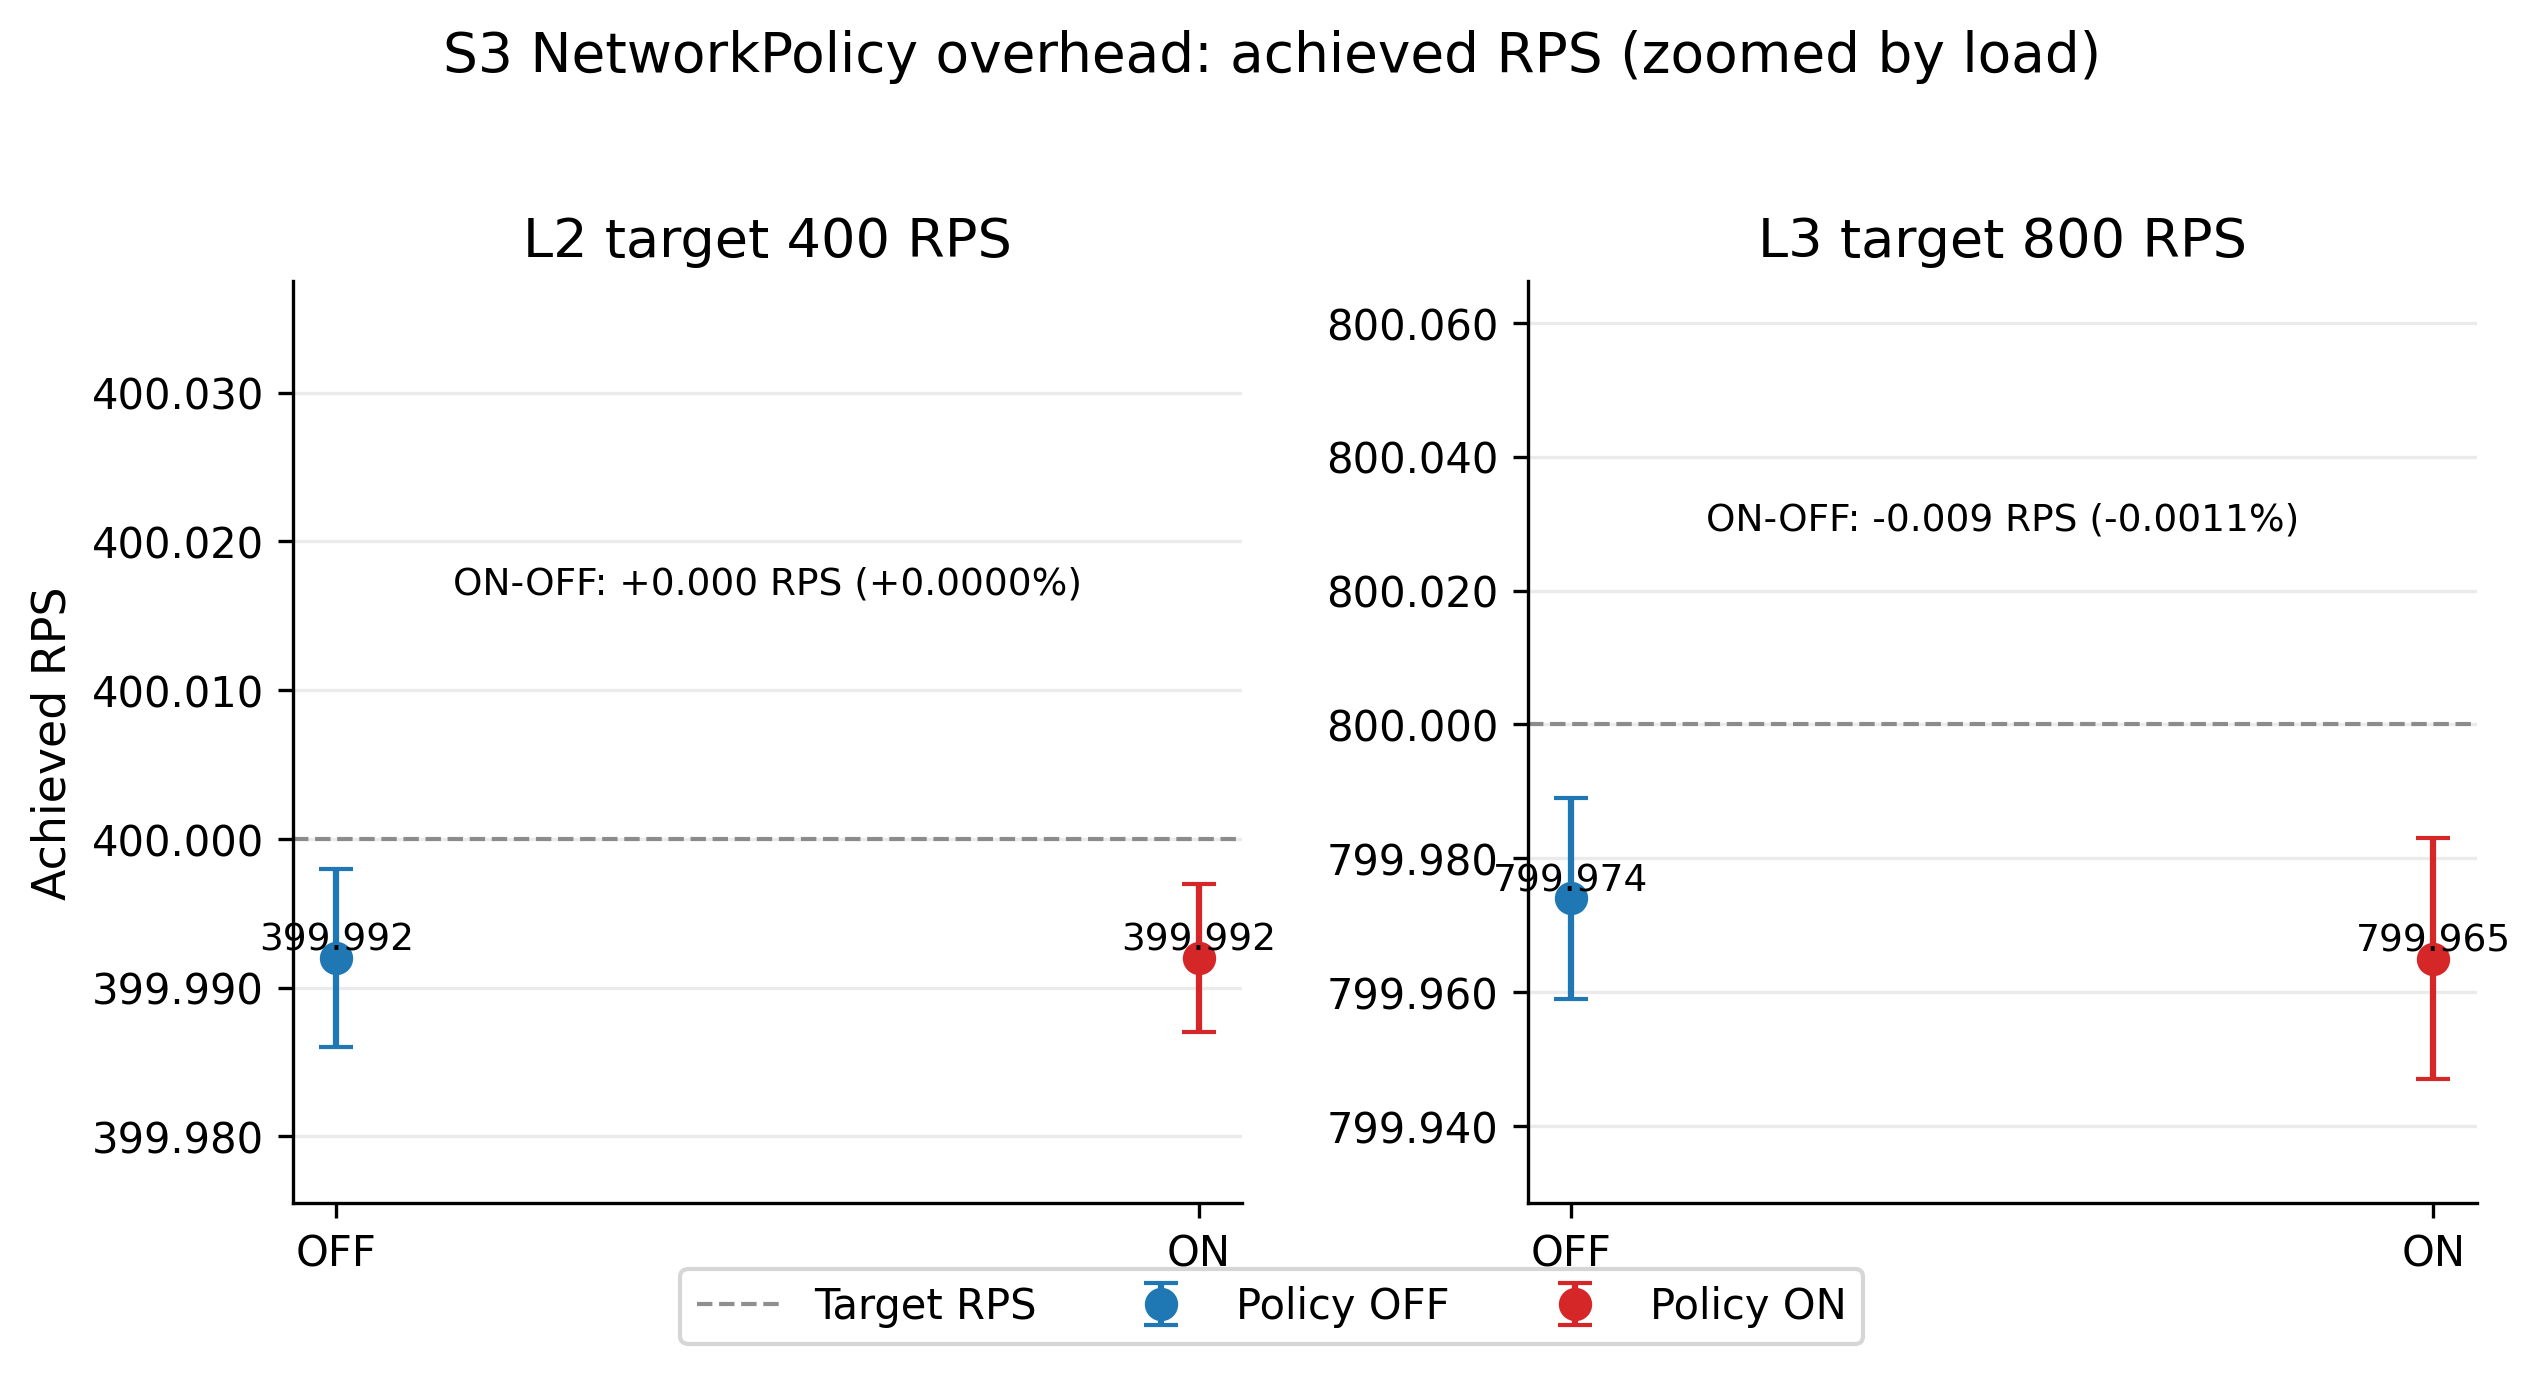

In [11]:
charts.chart_s3_policy_rps(aggregated, OUT_DIR)
show_fig("fig-s3-policy-overhead-rps")


## Kết luận đọc notebook

Notebook này tái tạo lại từng figure theo đúng thứ tự dẫn dắt của luận văn (thesis narrative). Khi viết báo cáo, hãy sử dụng file `docs/thesis_figure_analysis.md` để lấy các đoạn diễn giải chi tiết và cách dùng thuật ngữ an toàn cho luận văn (thesis-safe wording).

**Checklist tránh khẳng định quá mức (overclaim):**

* **L3:** Được hiểu là mức tải gây áp lực cao hoặc gây vọt độ trễ đuôi (high-stress/tail-spike load), không phải là điểm bão hòa tuyệt đối (saturation point).
* **S1:** Có bằng chứng thực nghiệm tốt hơn ở các mức L2/L3; riêng mức L1 p99 chỉ nên coi là một xu hướng tham khảo.
* **S2:** Bắt buộc phải phân tích theo từng giai đoạn (phase-aware); cần nêu rõ giai đoạn **L2 Burst 1** là một ngoại lệ so với các giai đoạn khác.
* **Repeatability:** Với số lần lặp $n=3$, kết quả này dùng để mô tả đặc tính của bộ dữ liệu hiện tại, không phải là một ước lượng thống kê đầy đủ cho mọi trường hợp.
* **S3:** Đây là phép so sánh giữa Policy OFF và ON trong cùng Mode B; tuyệt đối không khẳng định về các cơ chế như "Hubble DROPPED" nếu các minh chứng kỹ thuật (artifacts) không hỗ trợ trực tiếp.